In [1]:
import sys
sys.path.append('../')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from method_scripts.results_class import *
from method_scripts.base_method import *

from time import time

In [ ]:
for dname, settings in dataset_settings:
    path = f"../datasets/{dname}.csv"
    n_estimators = settings["num_estimators"]
    X_new, y, header_new, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, n_estimators)
    print(X_new.shape, y.shape)

(4521, 25) (4521,)
(6907, 22) (6907,)
(768, 50) (768,)
(4601, 30) (4601,)
(24508, 33) (24508,)


In [13]:
def get_all_datasets_results(methods, dataset_names):
    all_datasets_results = {}
    for dname in dataset_names:
        all_columns = set()
        method_dfs = {}
        for method in methods:
            data = load_results(f"../analysis/results/methods/{method}.pkl")
            df = pd.DataFrame(data)
            df = df[df["dataset"] == dname]
            method_dfs[method] = df
            all_columns.update(df.columns)
        all_columns = list(all_columns)

        dfs = []
        for method, df in method_dfs.items():
            df = df.reindex(columns=all_columns)
            df["method"] = method
            dfs.append(df)
        combined_df = pd.concat(dfs, ignore_index=True)
        all_datasets_results[dname] = combined_df 
    return all_datasets_results

def populate_all_datasets_results(all_datasets_results, limit=10):
    for dname, df in all_datasets_results.items():
        print(dname)
        accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
        model_count, headers = [], []

        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, df.iloc[0]['n_estimators'])
        for i, row in df.iterrows():
            w_rset = row["w_rset"]
            w_opt = row["w_opt"]
            predictions = row["predictions"]
            l2 = 0.001
            print(f"\t{i}: {w_rset.shape[0]}")

            if w_rset.shape[0] == 0:
                accuracy.append(0)
                logistic.append(0)
                hamming.append(0)
                iou.append(0)
                euclidean.append(0)
                cosine.append(0)
                model_count.append(0)
                headers.append(new_header)
                feature_to_vi.append(0)
                continue

            accuracy.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="accuracy"))
            logistic.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p))
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=limit))

            iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=limit))
            euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=limit))
            cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=limit))
            model_count.append(w_rset.shape[0])
            headers.append(new_header)

            feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))

        df['accuracy'] = accuracy
        df['logistic'] = logistic
        df['hamming'] = hamming
        df['iou'] = iou
        df['euclidean'] = euclidean
        df['cosine'] = cosine
        df['model_count'] = model_count
        df['header'] = headers
        df['feature_to_vi'] = feature_to_vi

In [3]:
methods = [
    "uniform__ellipsoid_sampling",
    "uniform_surface_ellipsoid_sampling",
    "poisson__ellipsoid_sampling",
    "poisson_euclidean_ellipsoid_sampling",
    "permutation__ellipsoid_sampling",
    "permutation_poisson_ellipsoid_sampling",
    "blocking",
    "quadratic",
    "swapping",
    "hybrid",
]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

### Comparison

In [4]:
all_datasets_results = get_all_datasets_results(methods, dataset_names)

In [14]:
populate_all_datasets_results(all_datasets_results)

bank
	0: 142
	1: 108
	2: 105
	3: 150
	4: 160
	5: 145
	6: 100
	7: 326
	8: 204
	9: 593
compas
	0: 103
	1: 71
	2: 95
	3: 112
	4: 143
	5: 132
	6: 100
	7: 6906
	8: 216
	9: 732
diabetes
	0: 220
	1: 192
	2: 232
	3: 212
	4: 219
	5: 221
	6: 100
	7: 3
	8: 150
	9: 482
spambase
	0: 565
	1: 547
	2: 603
	3: 557
	4: 635
	5: 535
	6: 100
	7: 10000
	8: 110
	9: 431
mimic2
	0: 16
	1: 14
	2: 6
	3: 13
	4: 20
	5: 8
	6: 100
	7: 9917
	8: 834
	9: 2620


In [20]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        print(f"METHOD: {row['method']}")
        BaseGAMRSetMethod.get_loss(
            X, y,
            w_rset,
            loss_type=loss_type,
            verbosity=1,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )

def show_bar_plot(all_datasets_results, dname, metric):
    df = all_datasets_results[dname]
    plot_two_var_bar(df, "method", metric)

def show_gam(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['model_count'] == 0:
            continue
        print(f"method: {row['method']}")
        plot_gam(np.array(row['header'][1:]), row['w_rset'][:, 1:])

def show_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        print(f"method: {row['method']}, model_count: {row['model_count']}")
        if row['model_count'] == 0:
            continue

        feature_to_vi = row['feature_to_vi']
        plot_variable_importance(feature_to_vi)

def show_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        print(f"method: {row['method']}, model_count: {row['model_count']}")
        if row['model_count'] == 0:
            continue
        
        feature_to_vi = row['feature_to_vi']
        for k, v in sorted(feature_to_vi.items()):
            print(f"\t{k}: {max(v)} - {min(v)}")

METHOD: uniform__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041316925493118


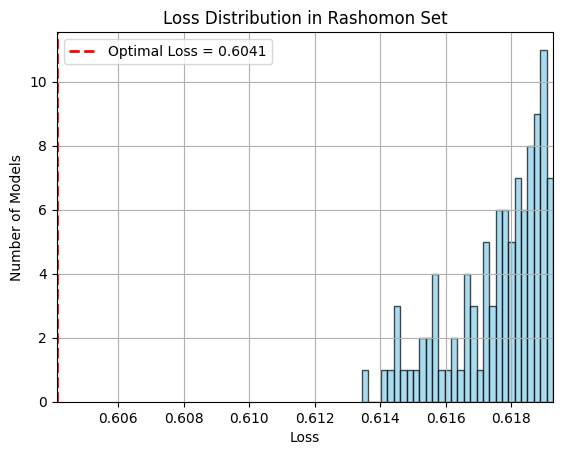

METHOD: uniform_surface_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604133058254075


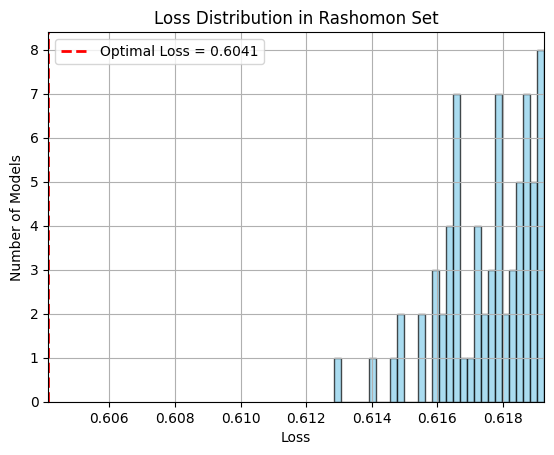

METHOD: poisson__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604135054008898


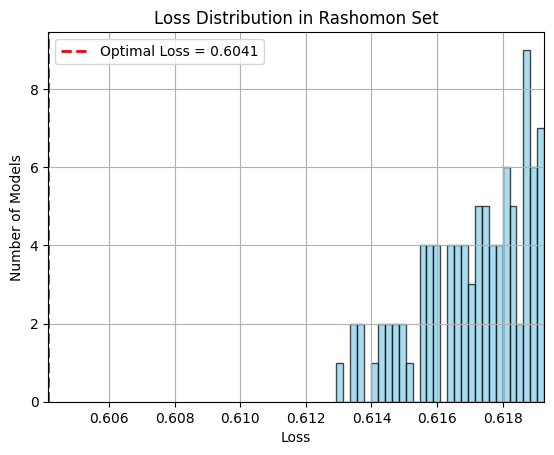

METHOD: poisson_euclidean_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041329259445345


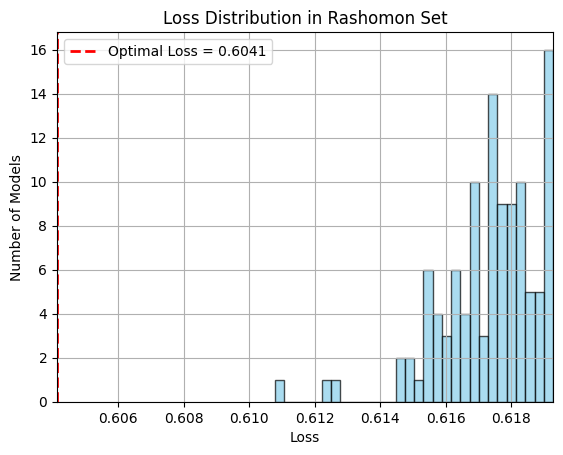

METHOD: permutation__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041339265932434


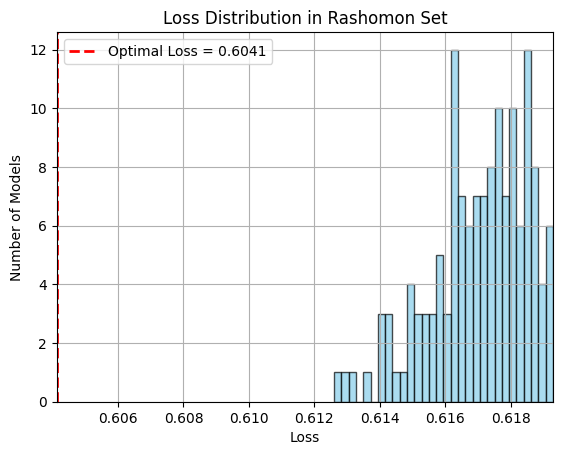

METHOD: permutation_poisson_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041337073353824


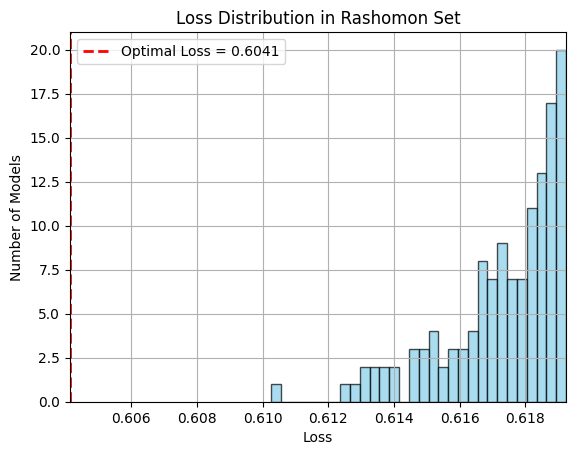

METHOD: blocking
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041333243225288


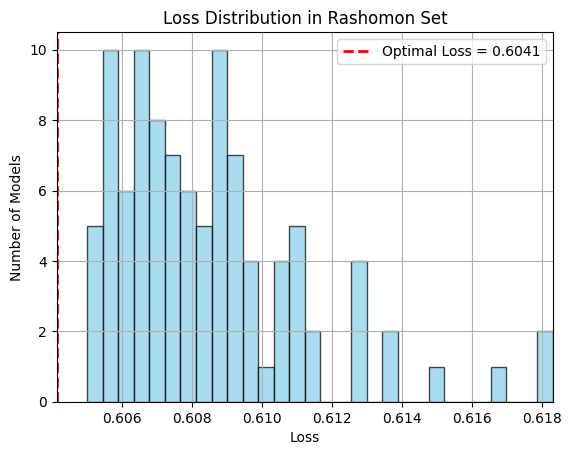

METHOD: quadratic
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604134571258694


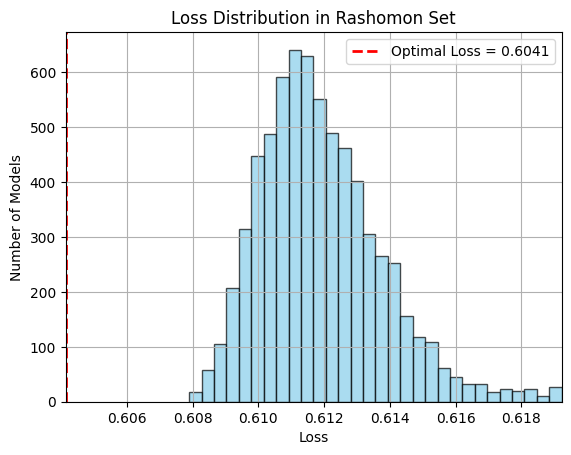

METHOD: swapping
optimal model
[ 0  1  2  3  4  5  6  7 12 13 14 15 16 17 18 19] 0.6023979724701976


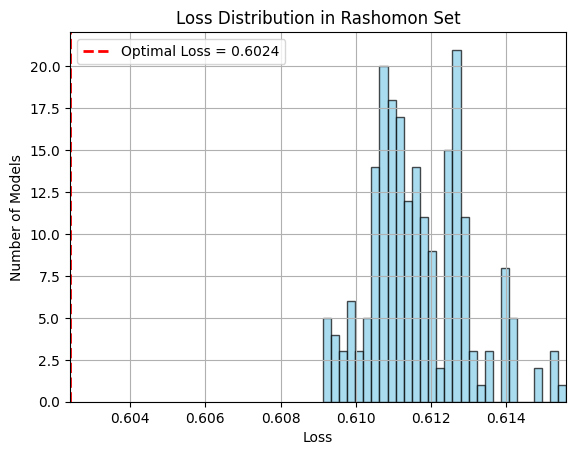

METHOD: hybrid
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.5998436797638811


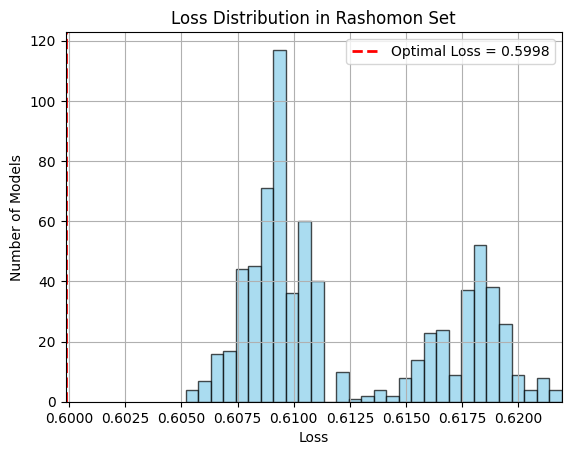

In [16]:
show_loss_distributions(all_datasets_results, "compas", "logistic")

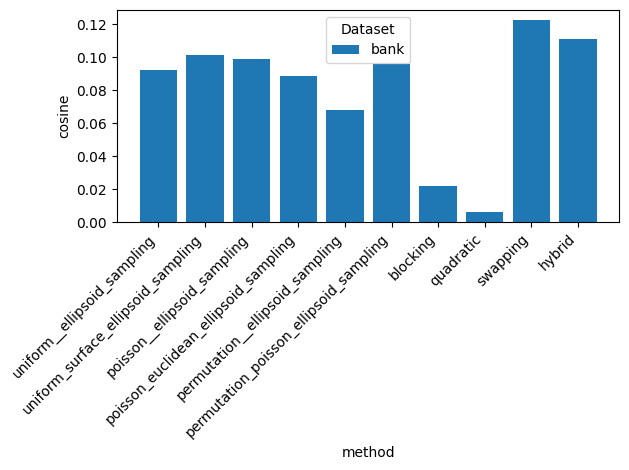

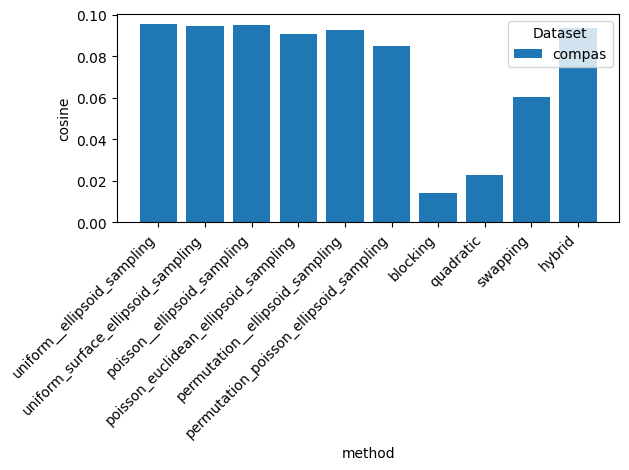

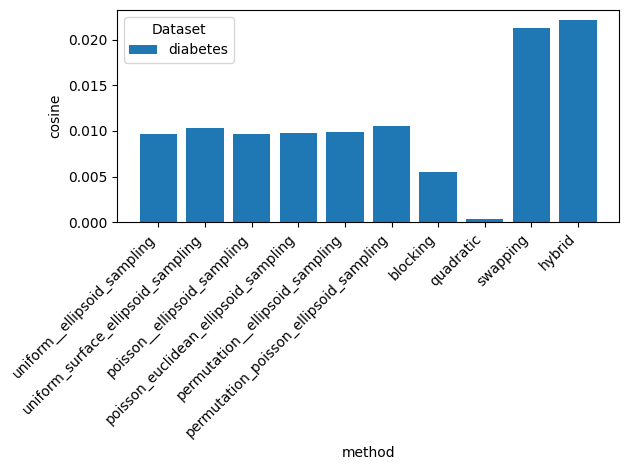

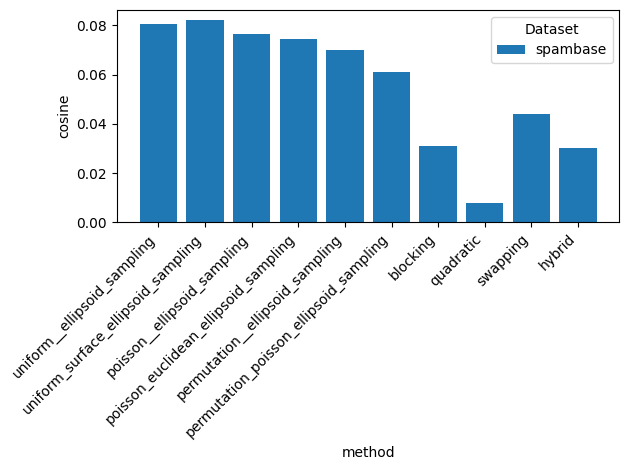

In [17]:
for dname in dataset_names[:-1]:
    show_bar_plot(all_datasets_results, dname, "cosine")

method: uniform__ellipsoid_sampling


100%|██████████| 142/142 [00:00<00:00, 6797.20it/s]


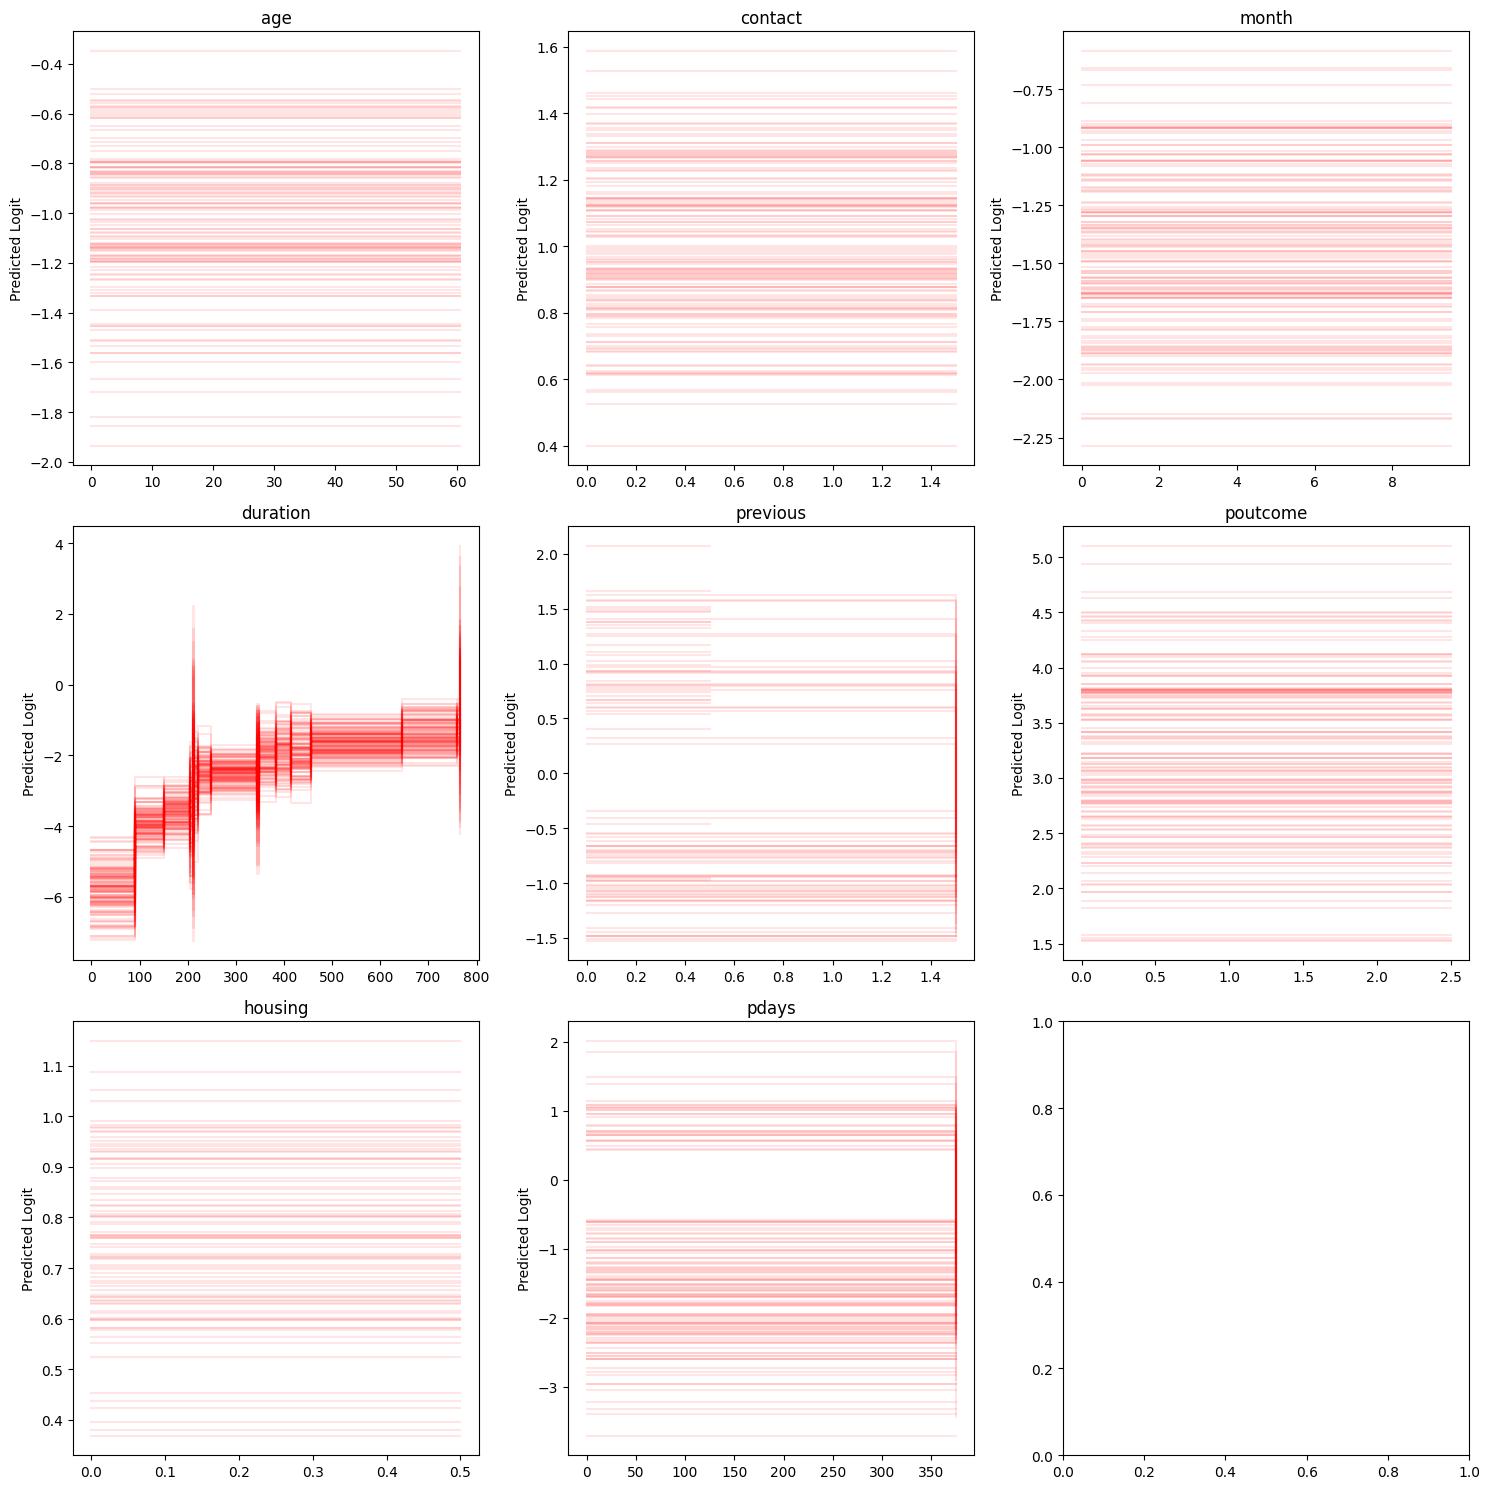

method: uniform_surface_ellipsoid_sampling


100%|██████████| 108/108 [00:00<00:00, 13124.67it/s]


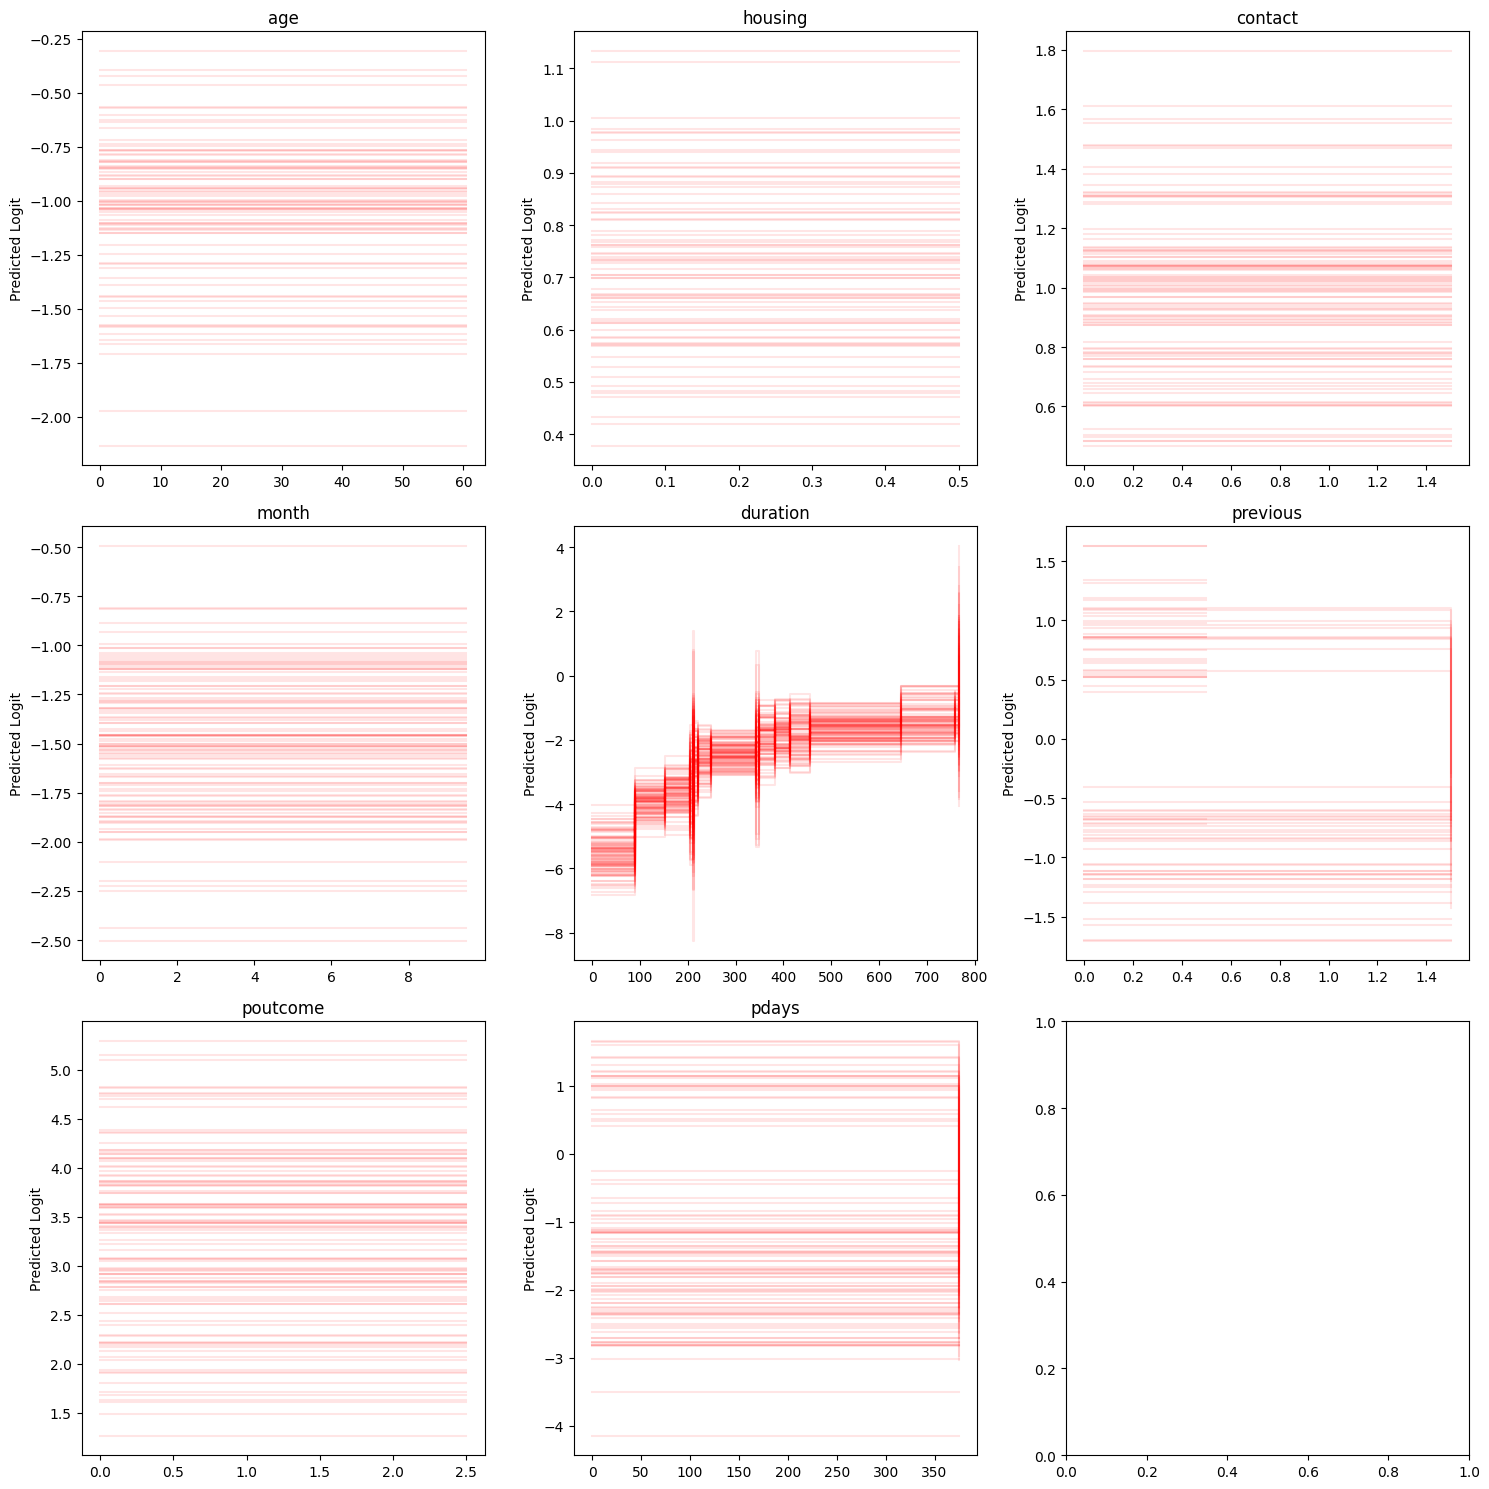

method: poisson__ellipsoid_sampling


100%|██████████| 105/105 [00:00<00:00, 13129.86it/s]


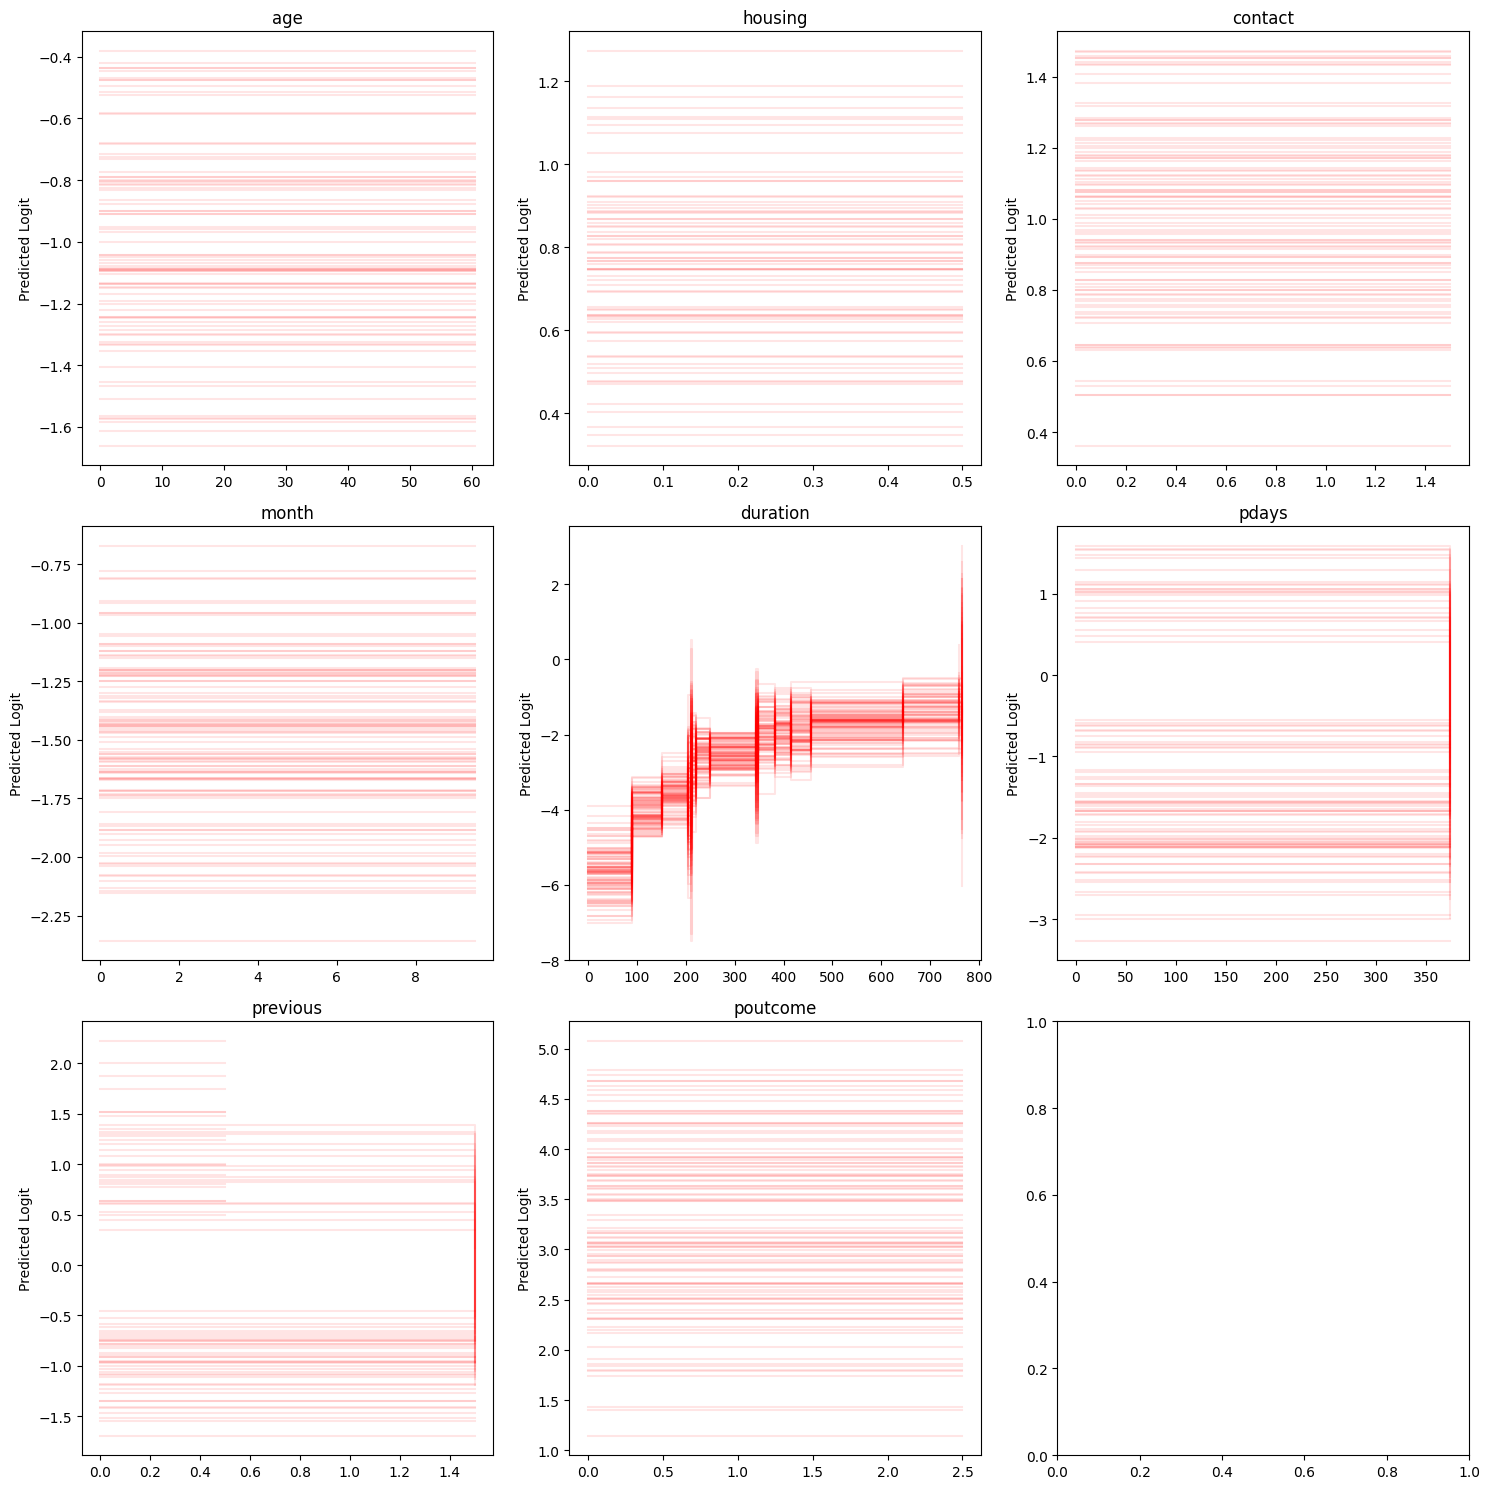

method: poisson_euclidean_ellipsoid_sampling


100%|██████████| 150/150 [00:00<00:00, 12488.50it/s]


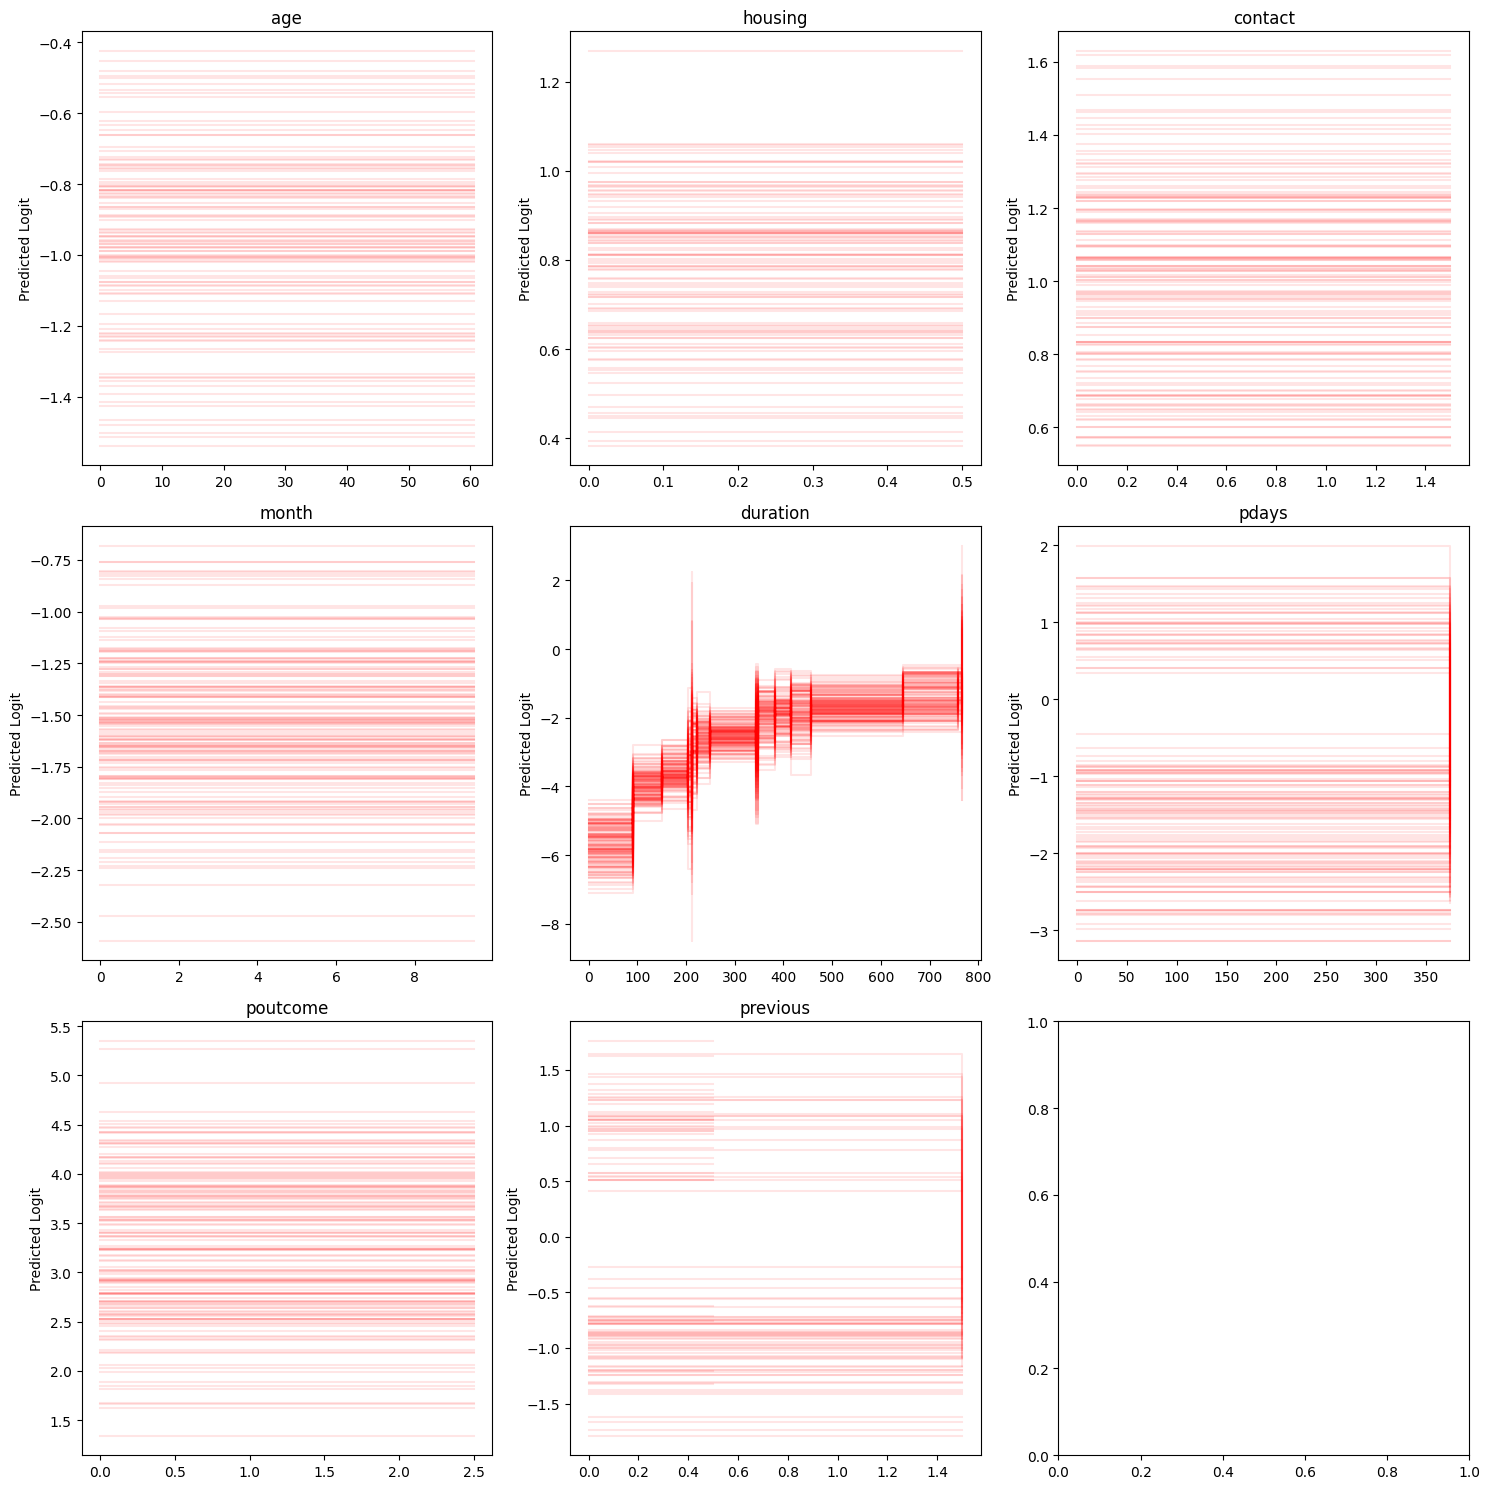

method: permutation__ellipsoid_sampling


100%|██████████| 160/160 [00:00<00:00, 12672.09it/s]


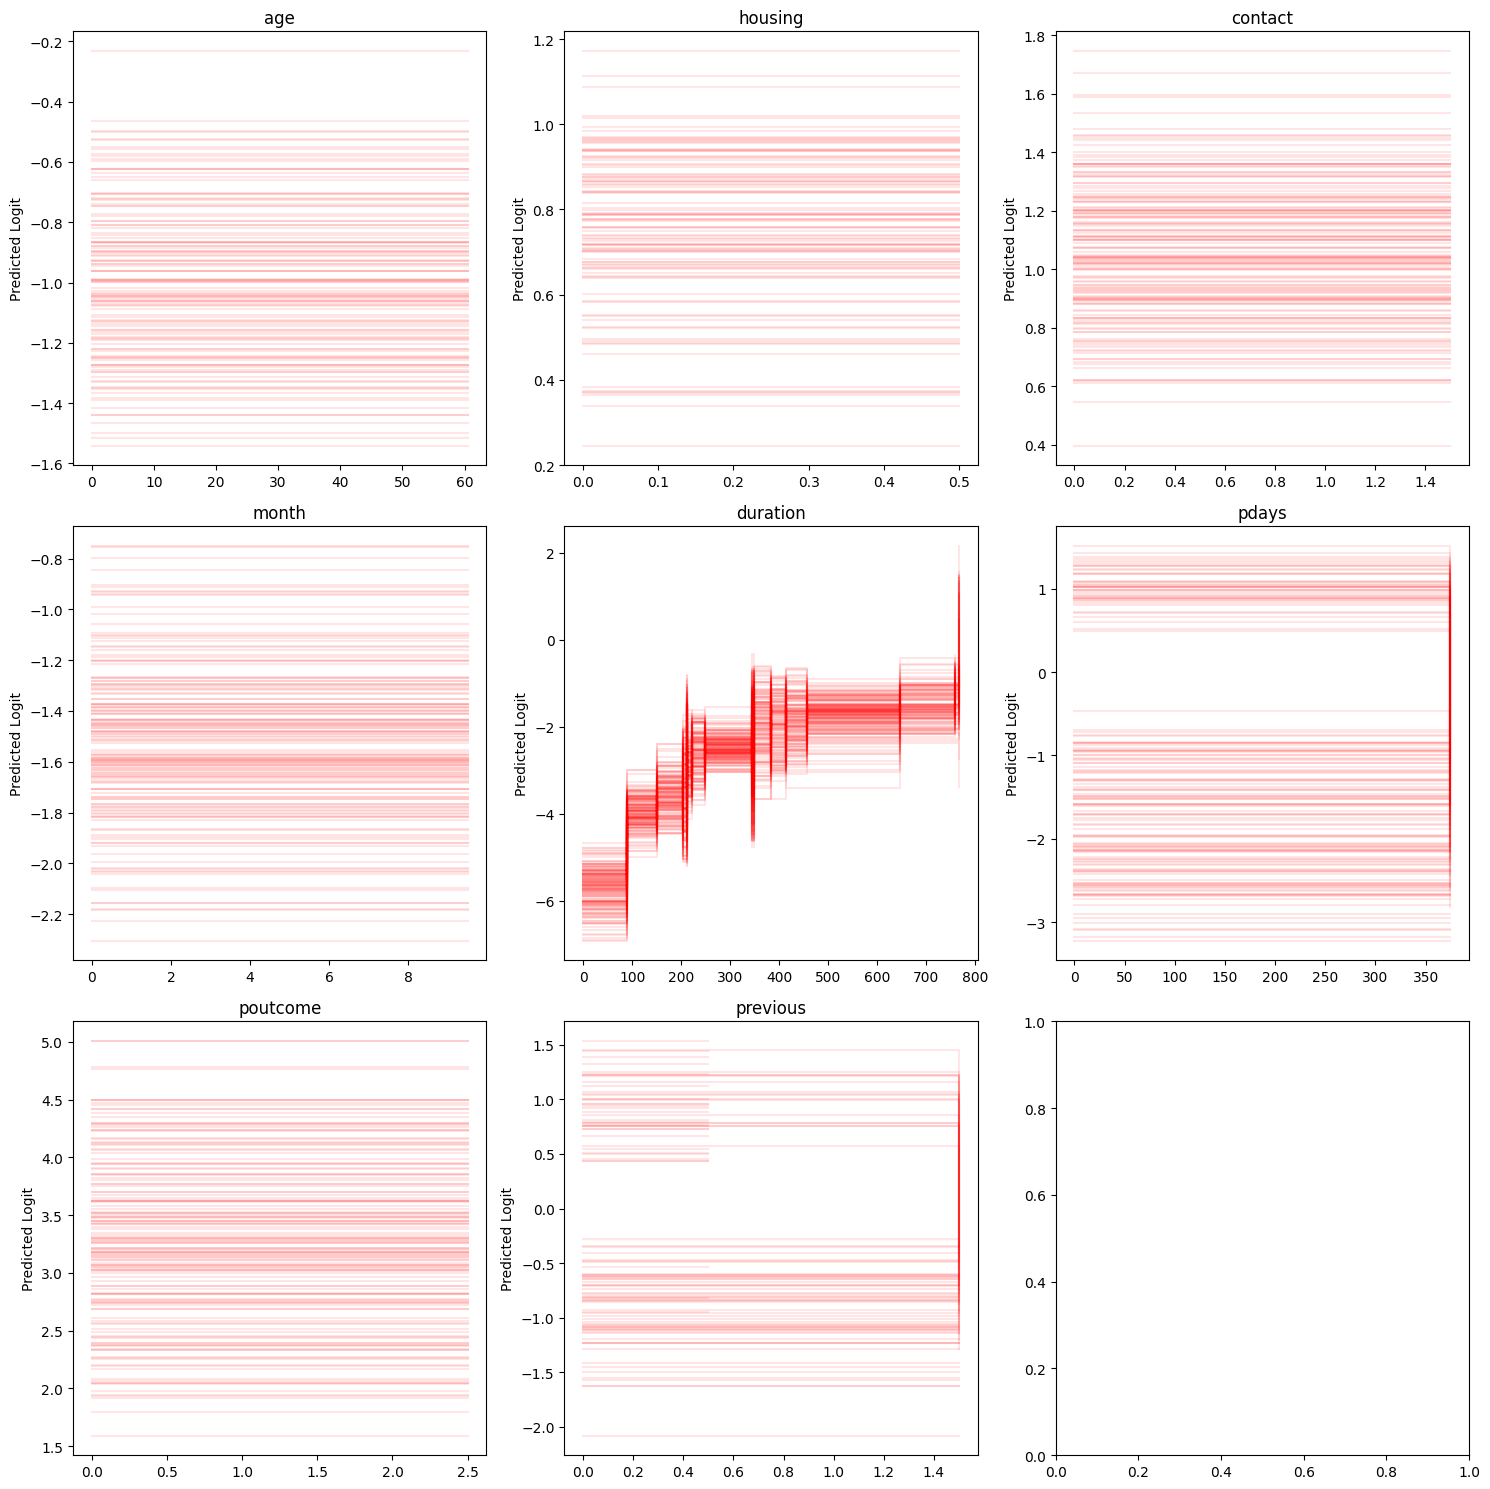

method: permutation_poisson_ellipsoid_sampling


100%|██████████| 145/145 [00:00<00:00, 12779.99it/s]


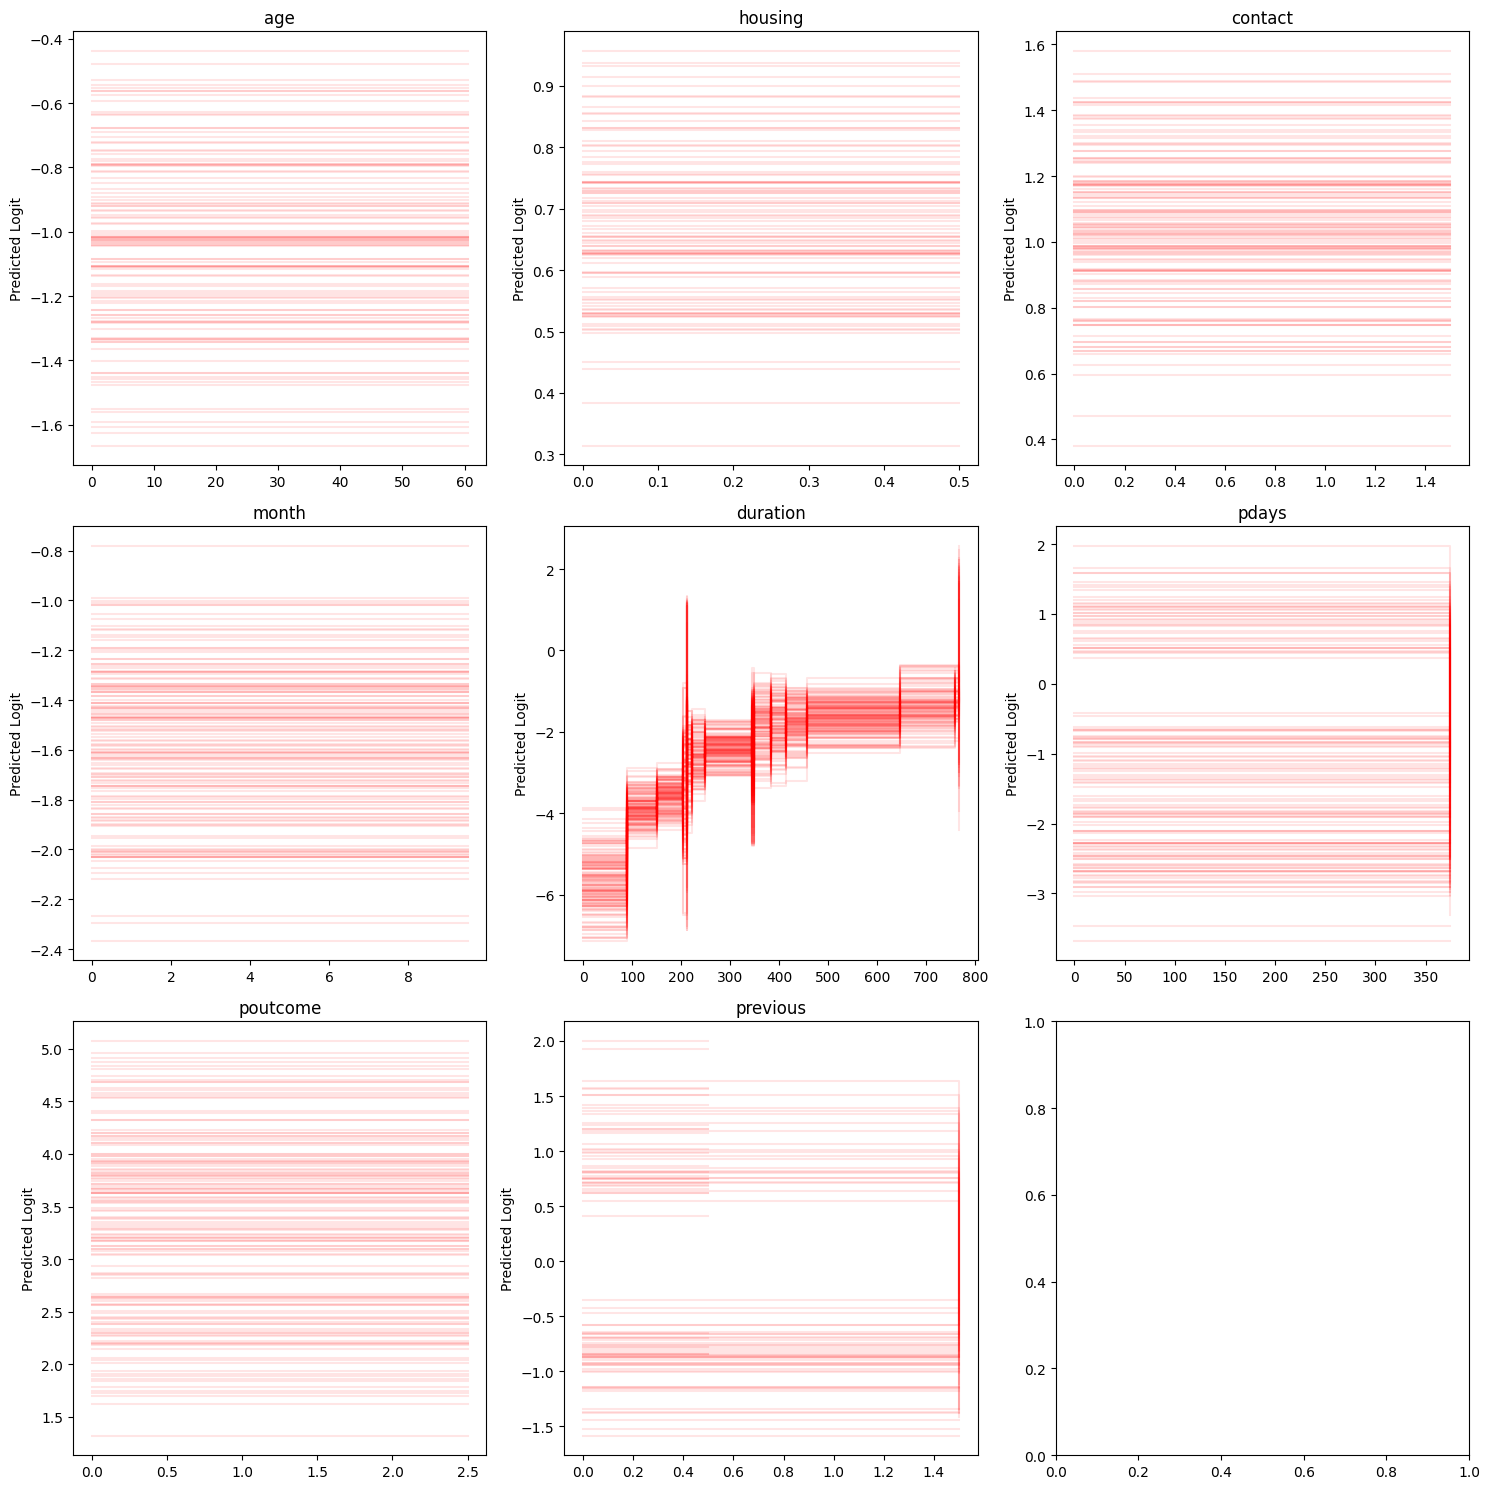

method: blocking


100%|██████████| 100/100 [00:00<00:00, 10933.77it/s]


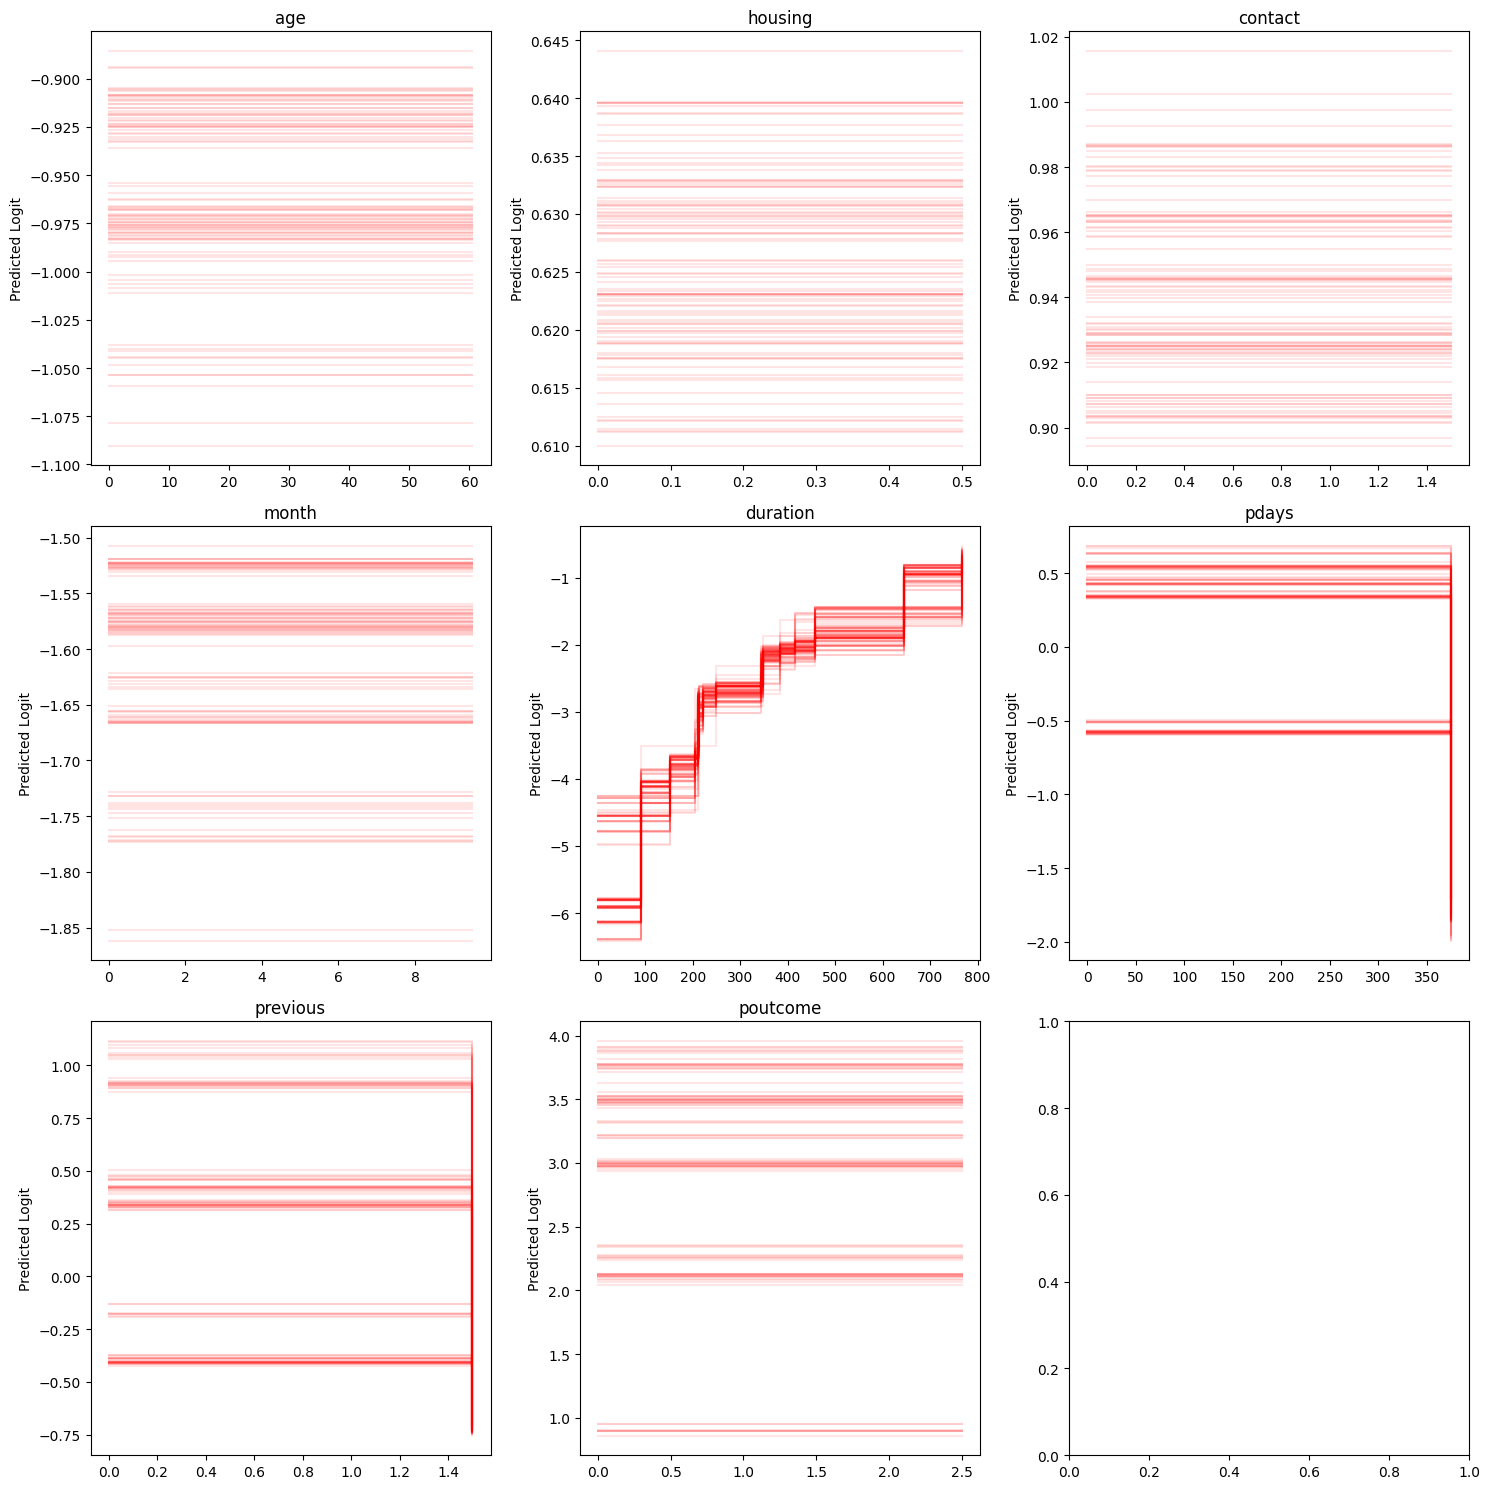

method: quadratic


100%|██████████| 326/326 [00:00<00:00, 14314.13it/s]


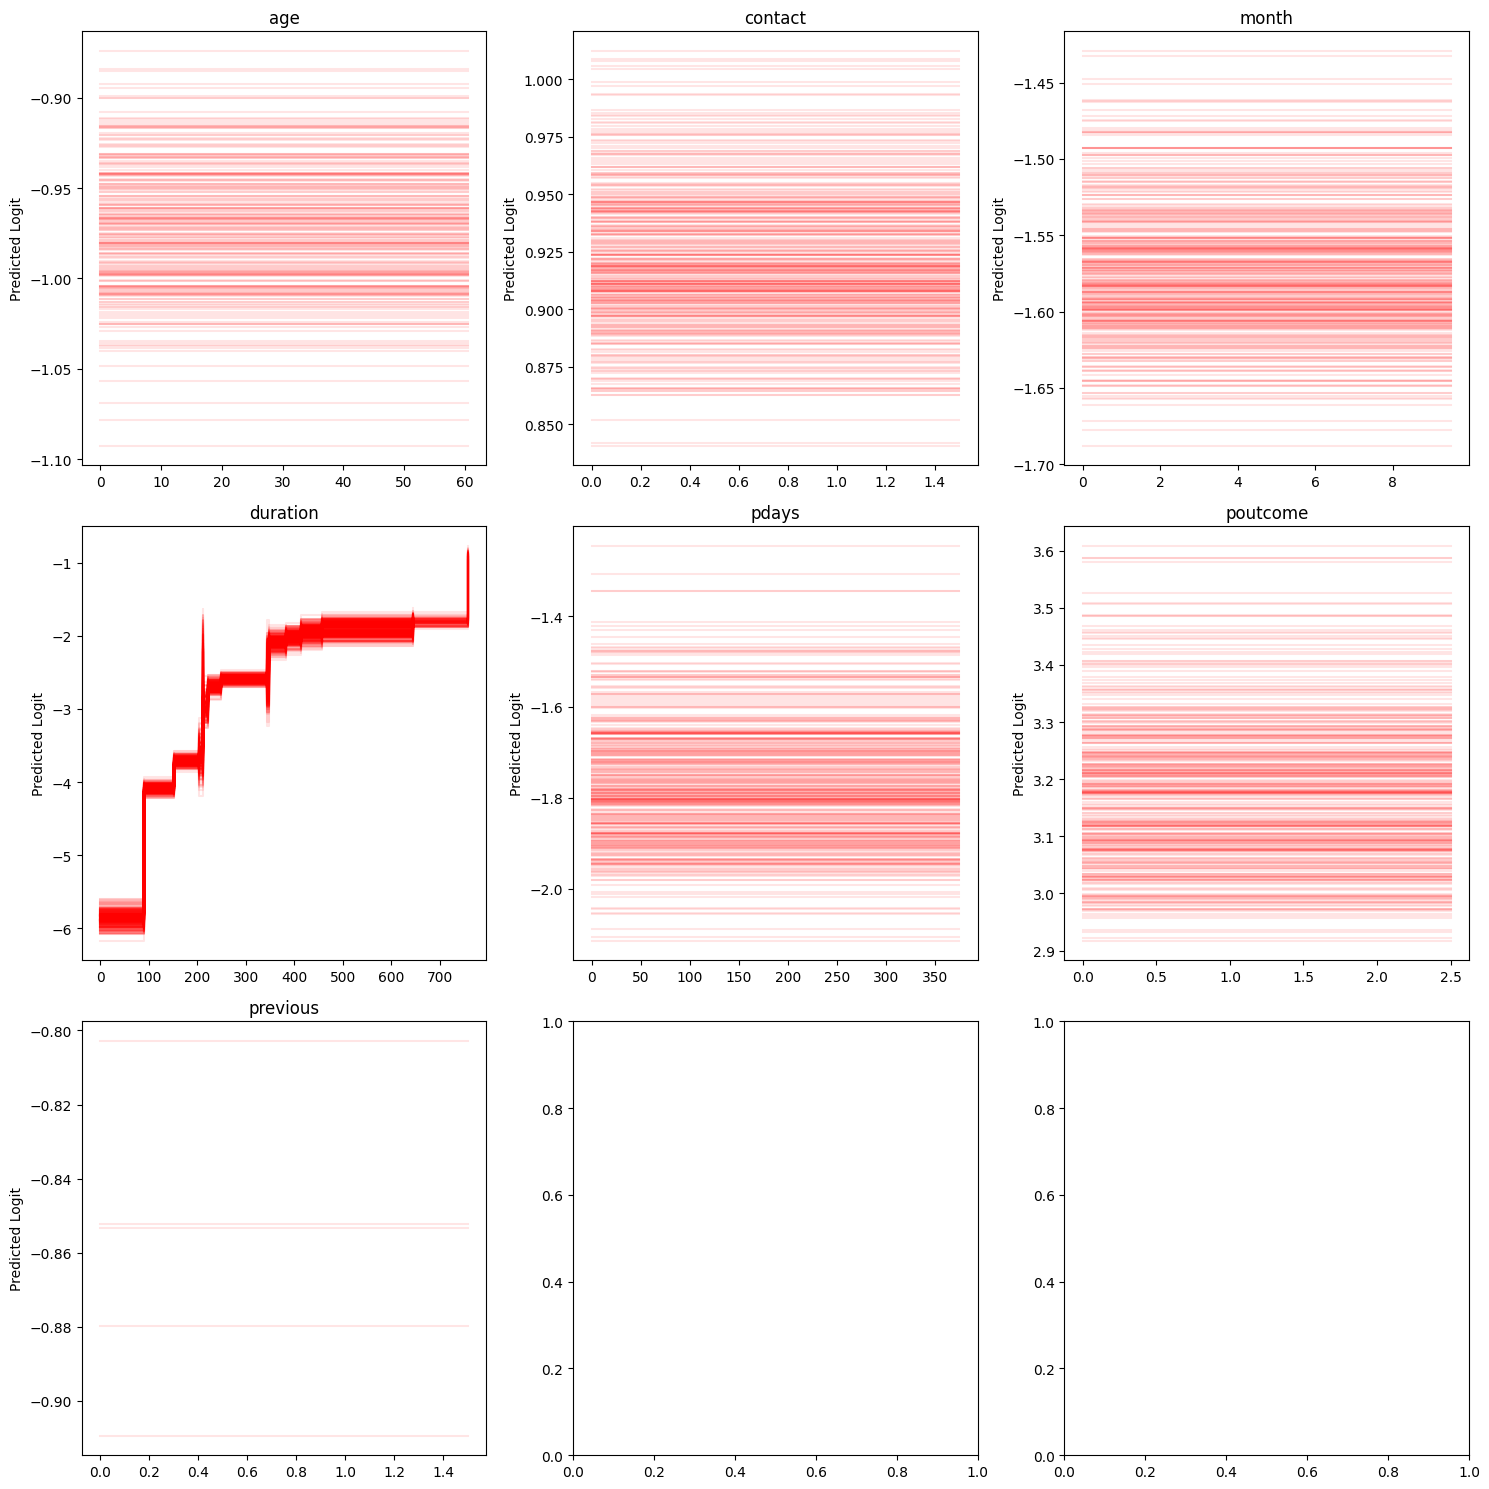

method: swapping


100%|██████████| 204/204 [00:00<00:00, 13154.35it/s]


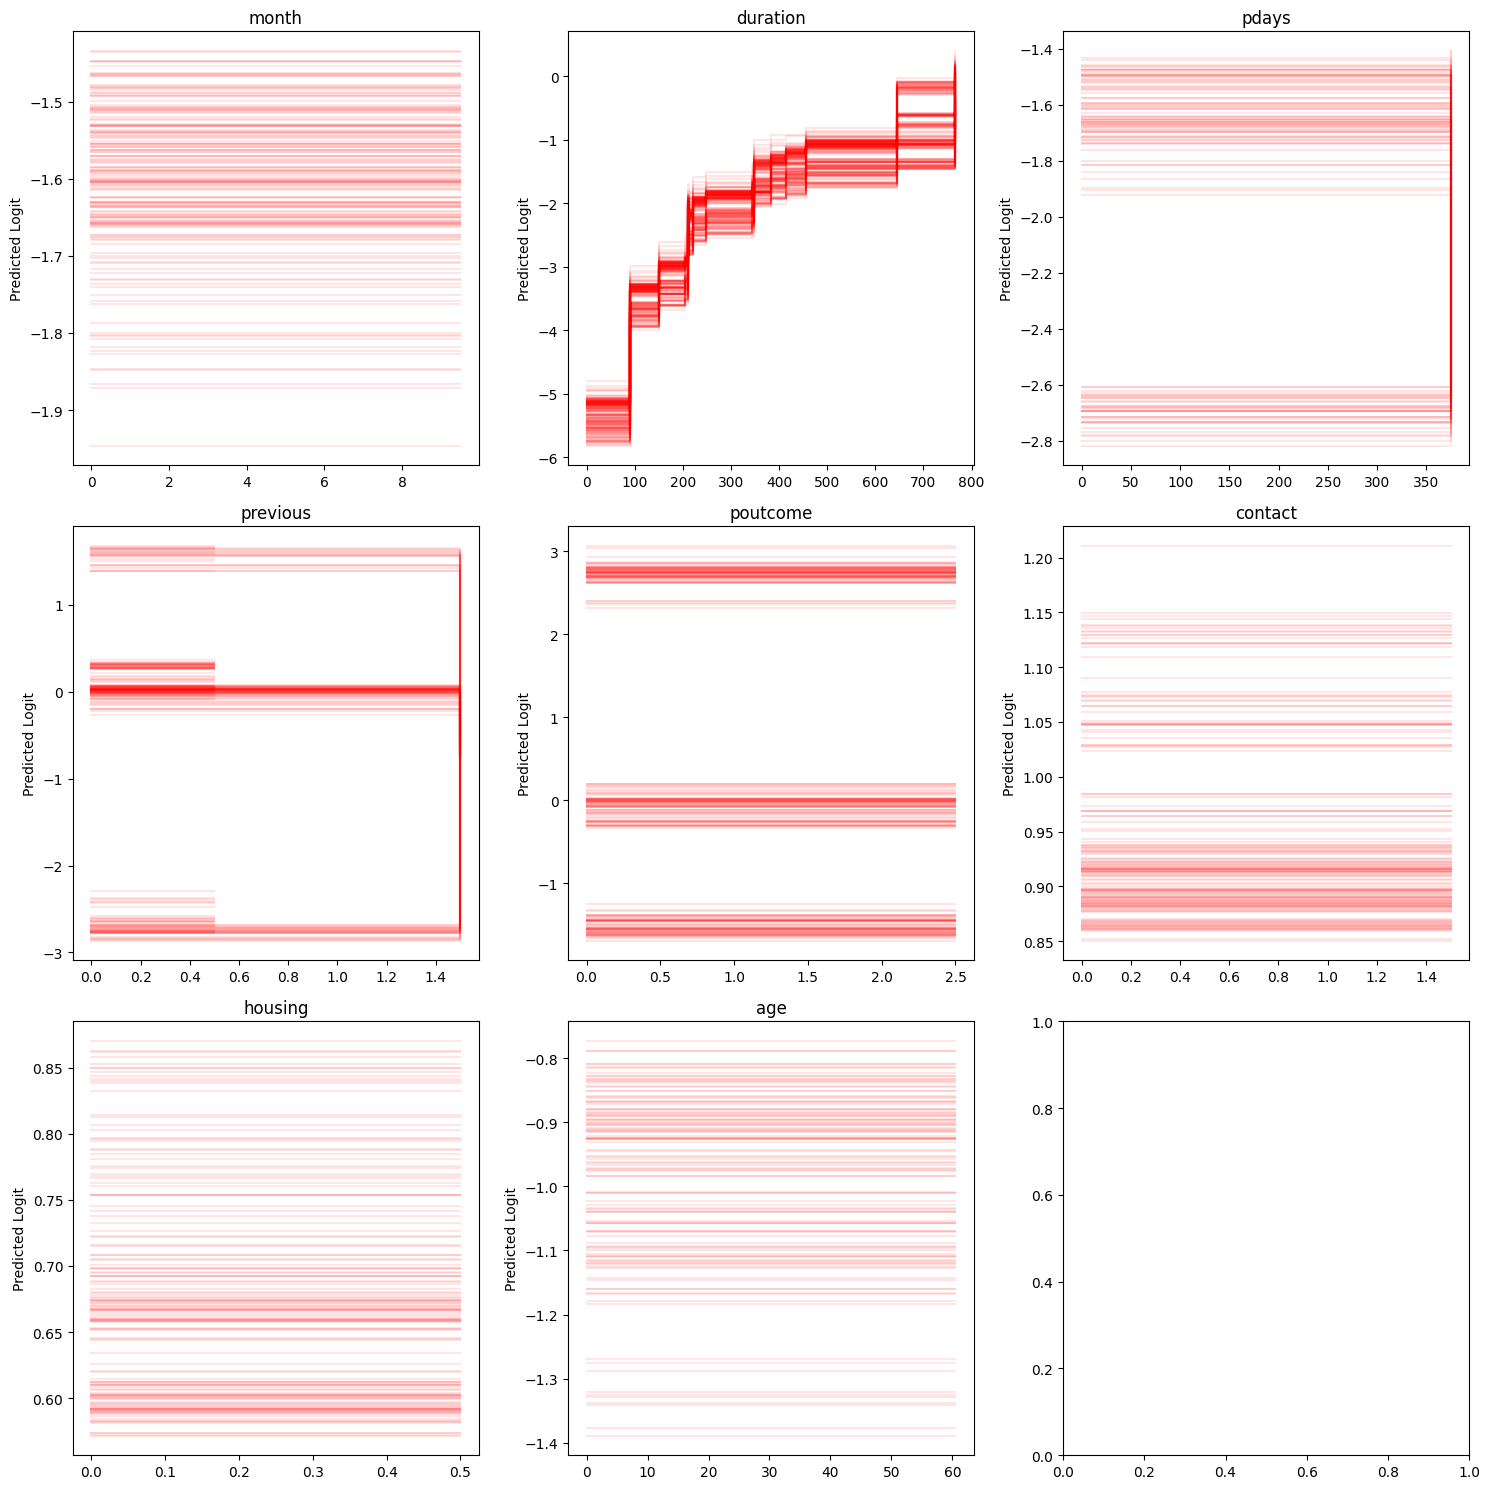

method: hybrid


100%|██████████| 593/593 [00:00<00:00, 13063.69it/s]


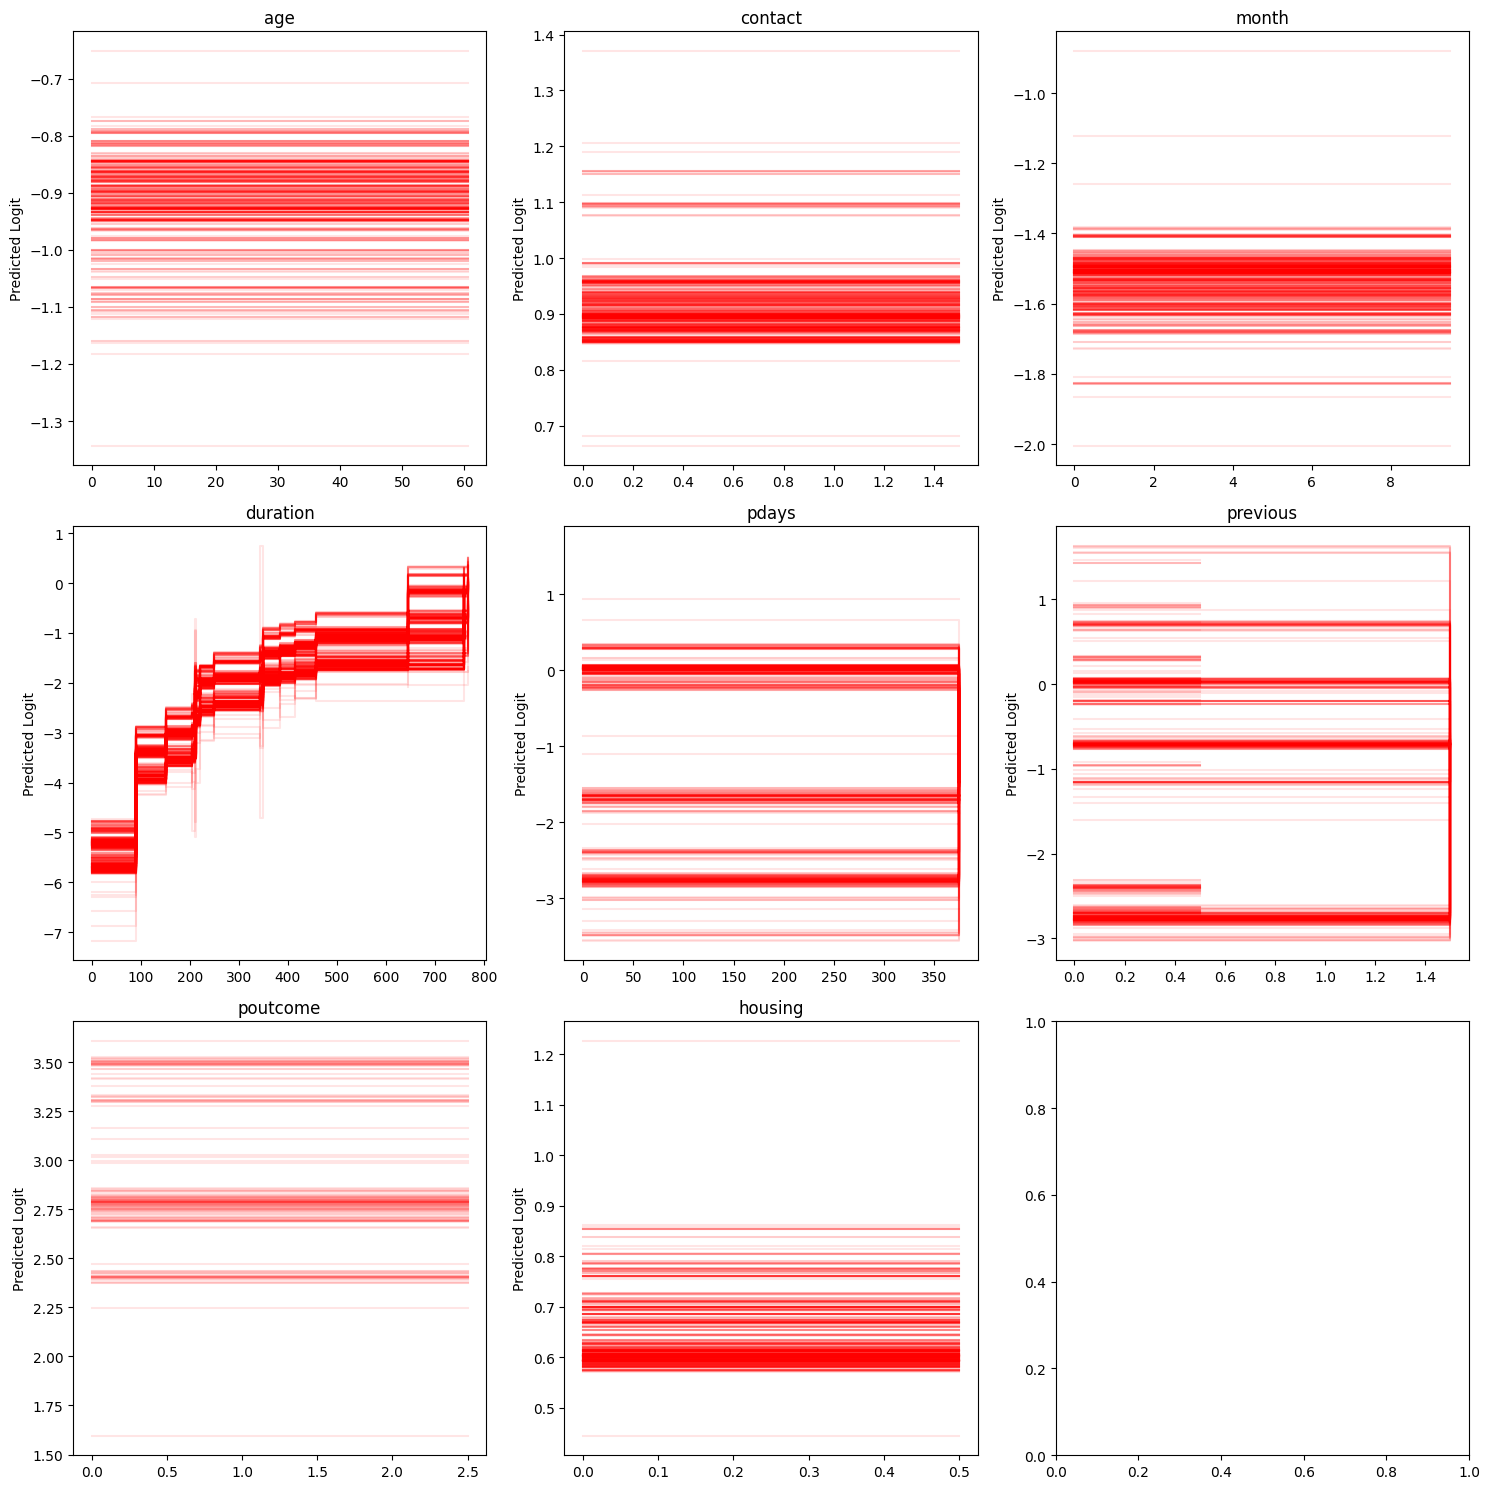

In [18]:
show_gam(all_datasets_results, 'bank')

method: uniform__ellipsoid_sampling, model_count: 142


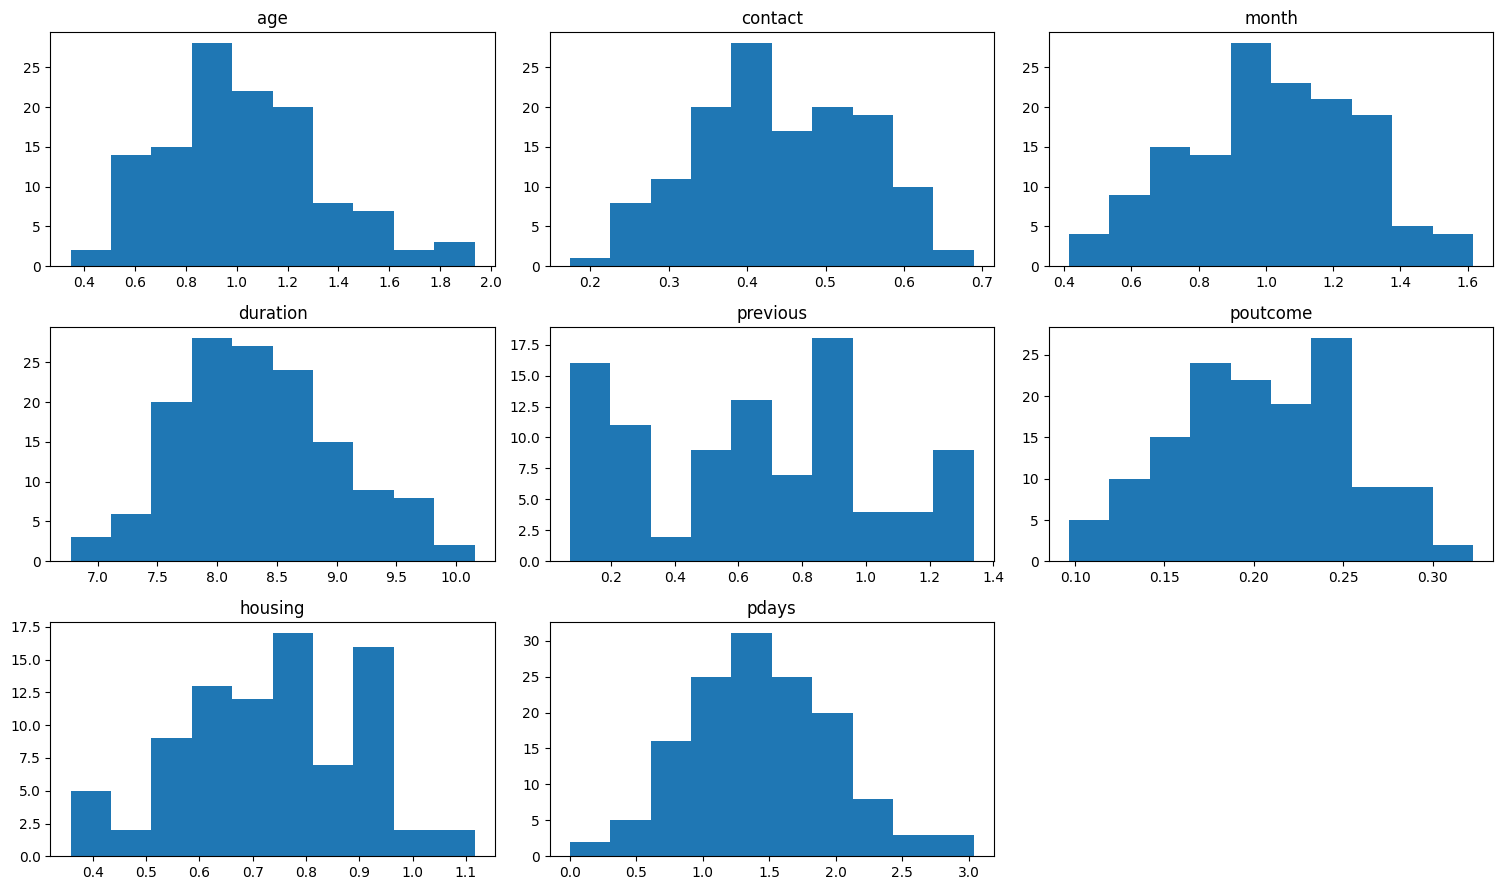

method: uniform_surface_ellipsoid_sampling, model_count: 108


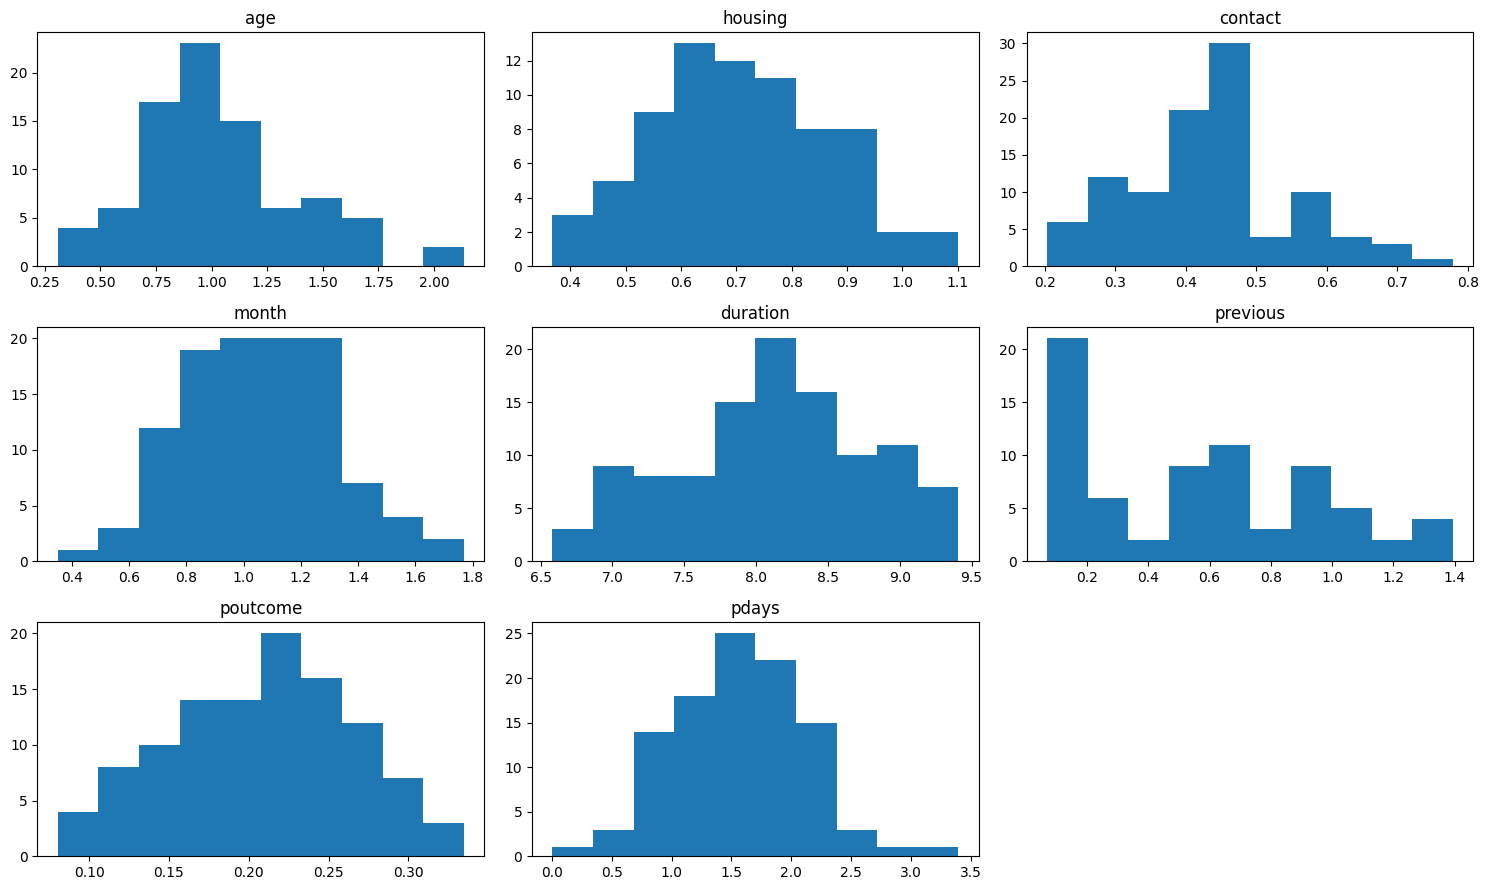

method: poisson__ellipsoid_sampling, model_count: 105


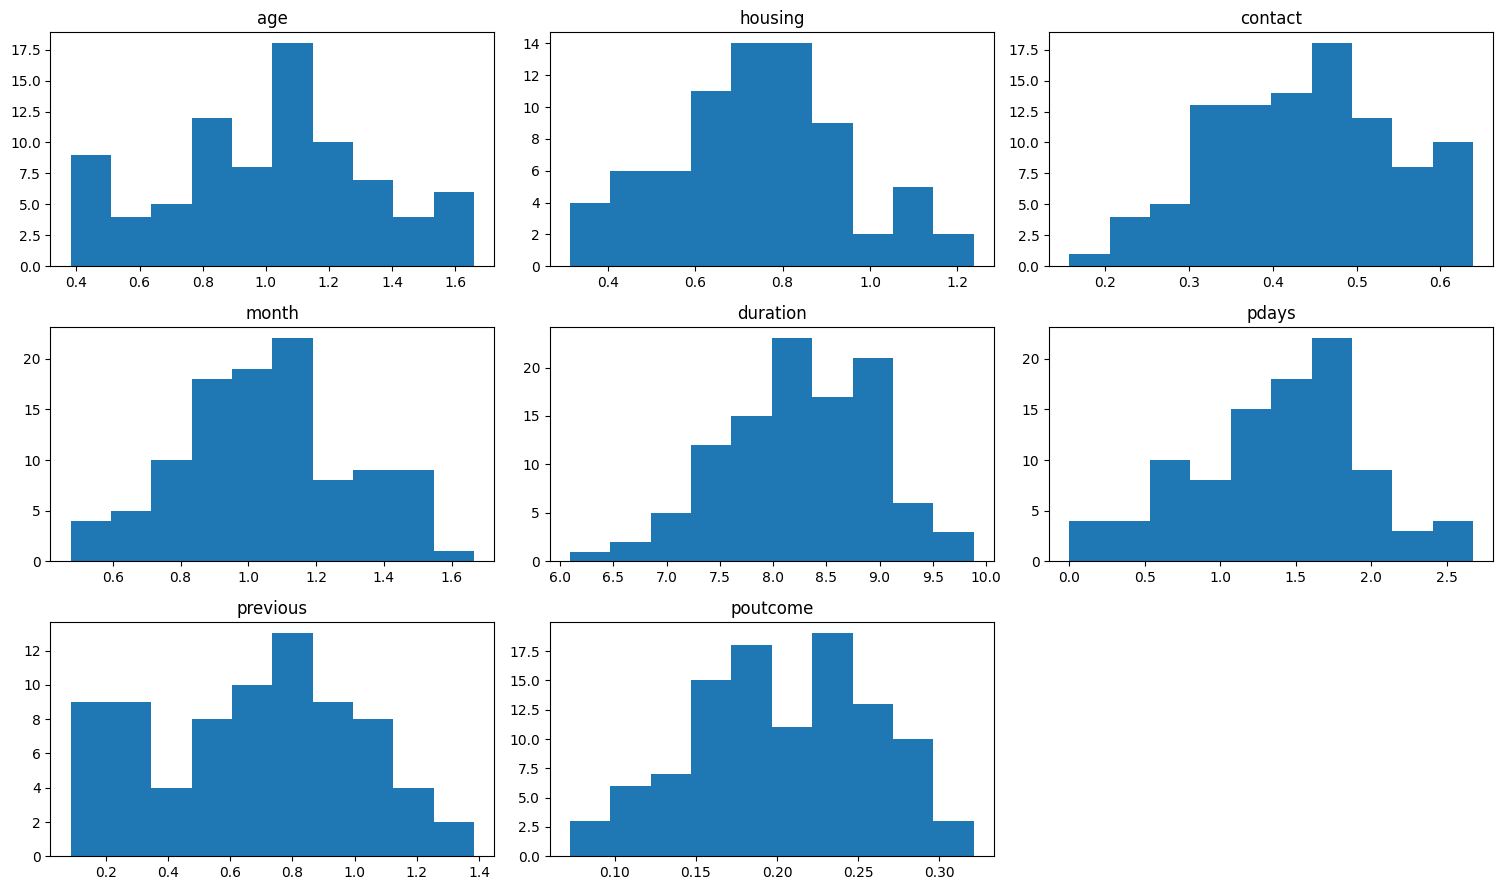

method: poisson_euclidean_ellipsoid_sampling, model_count: 150


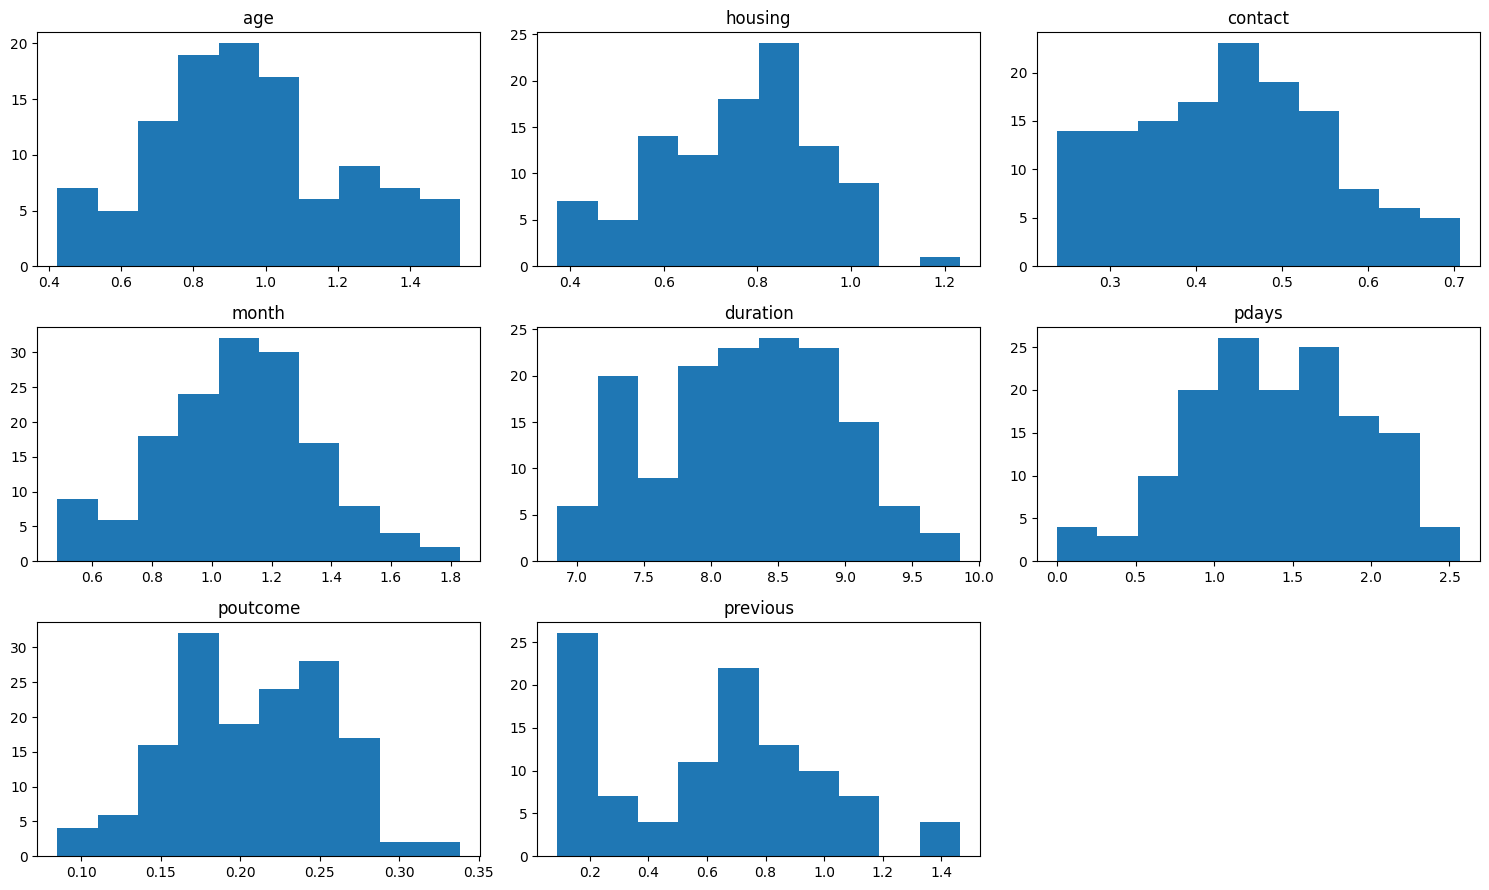

method: permutation__ellipsoid_sampling, model_count: 160


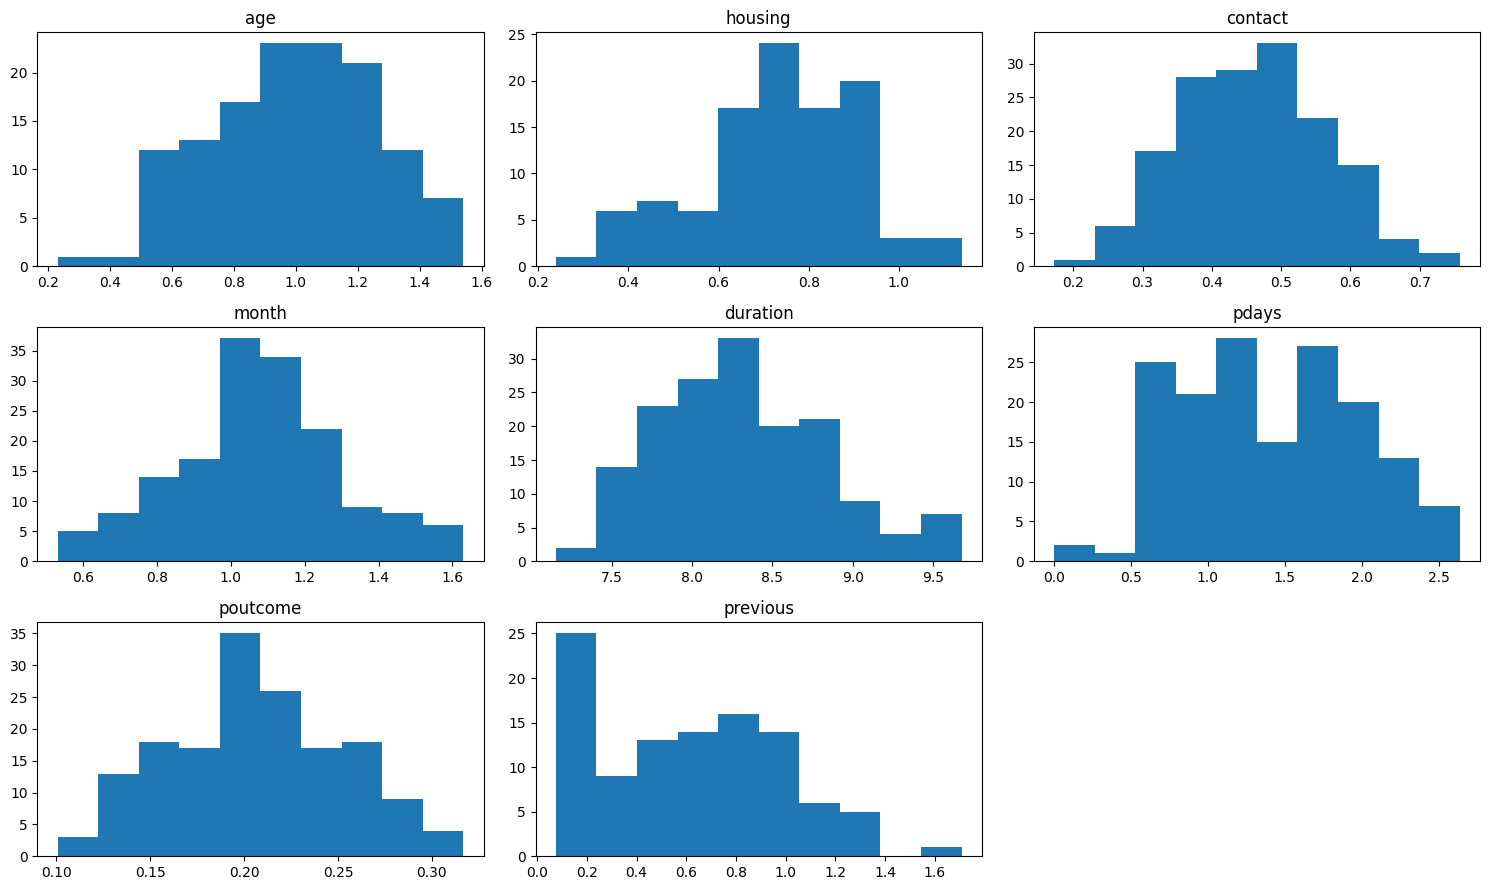

method: permutation_poisson_ellipsoid_sampling, model_count: 145


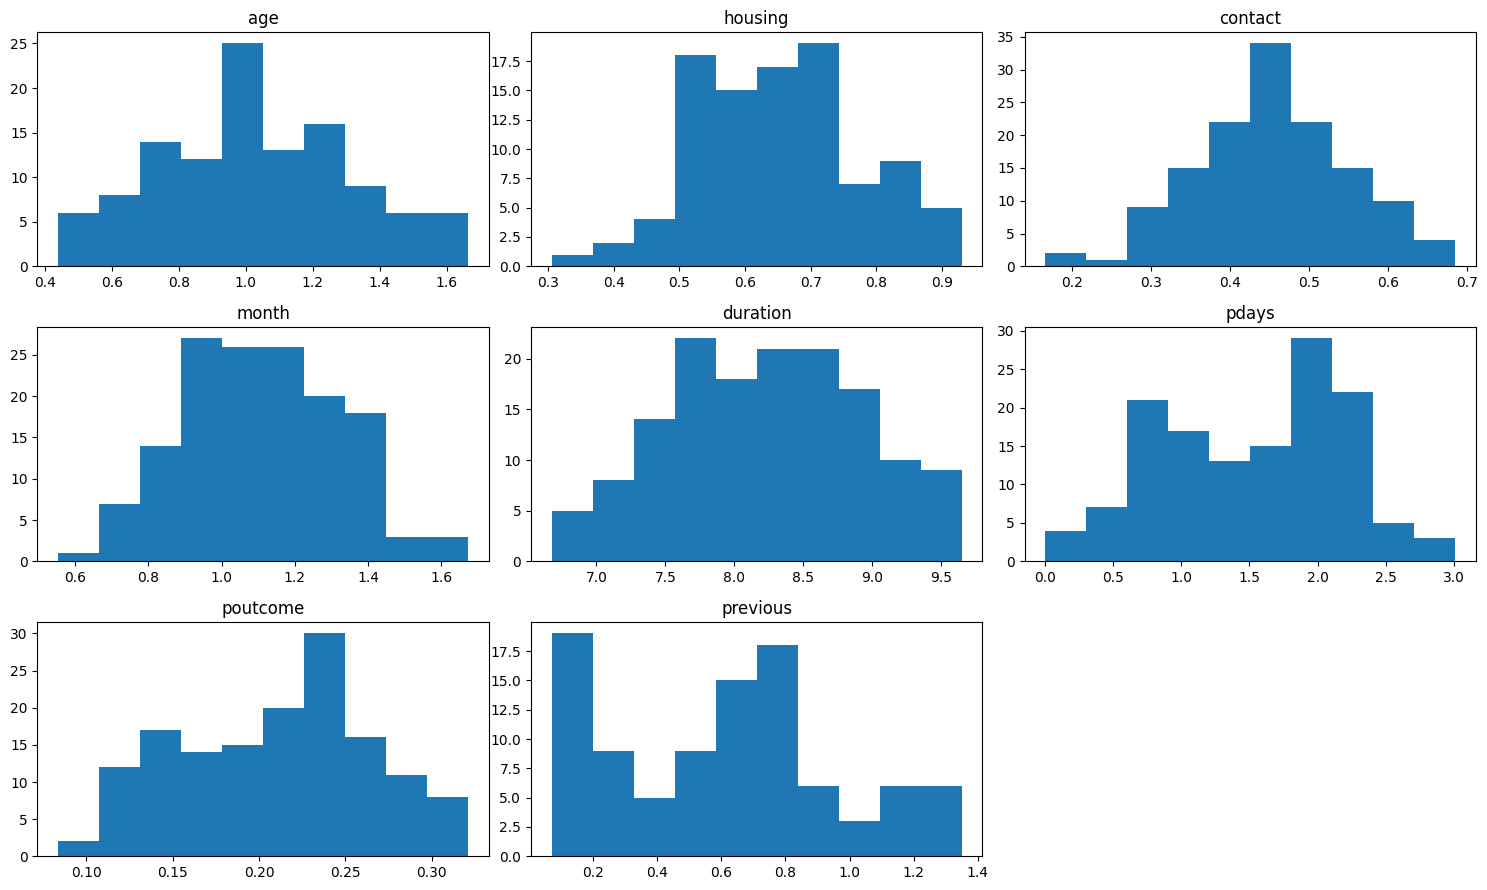

method: blocking, model_count: 100


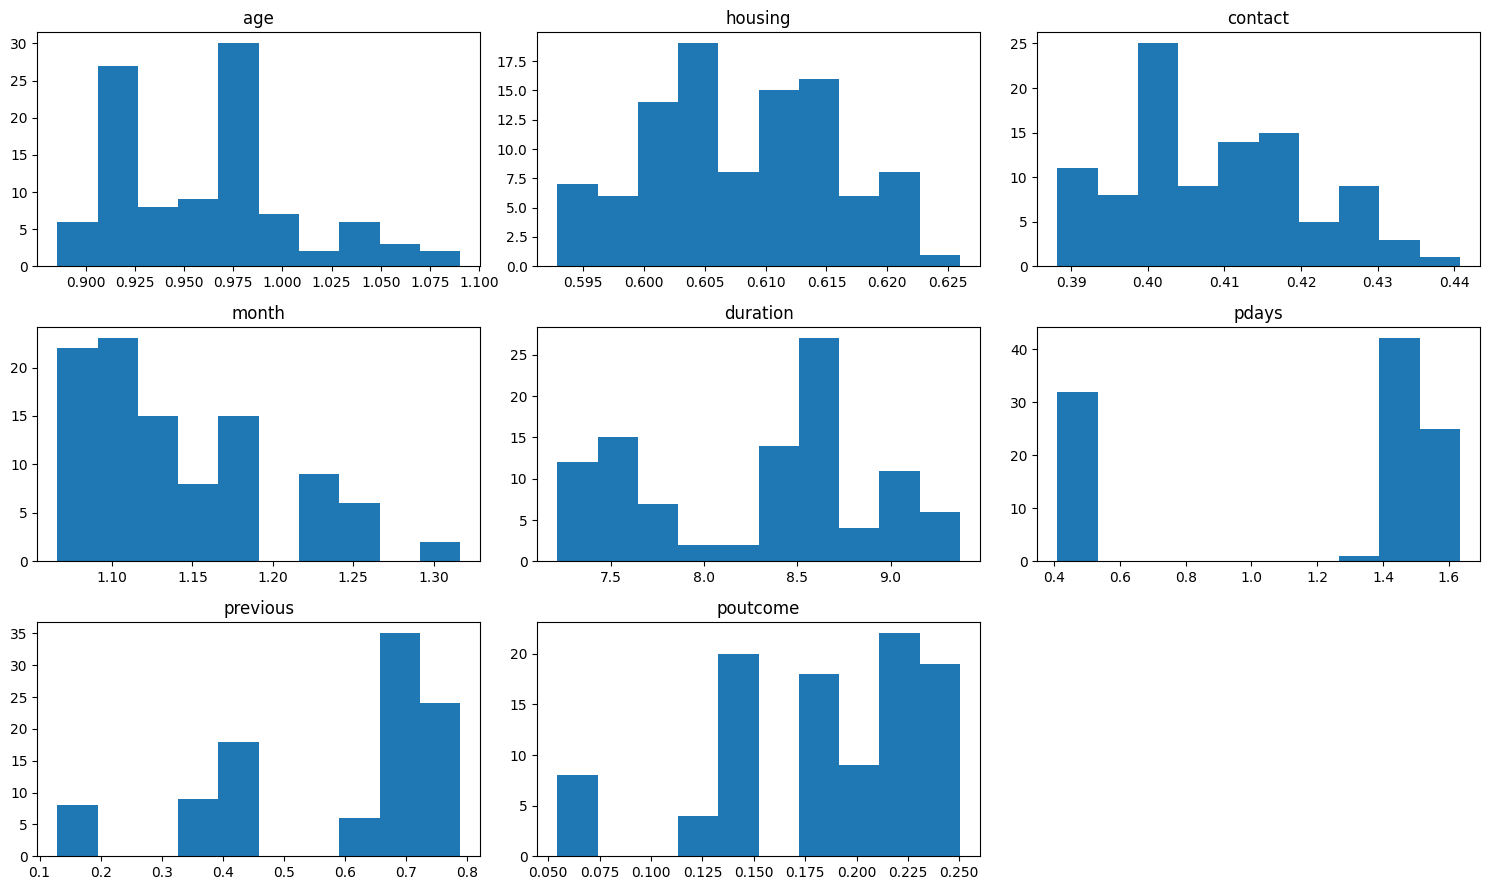

method: quadratic, model_count: 326


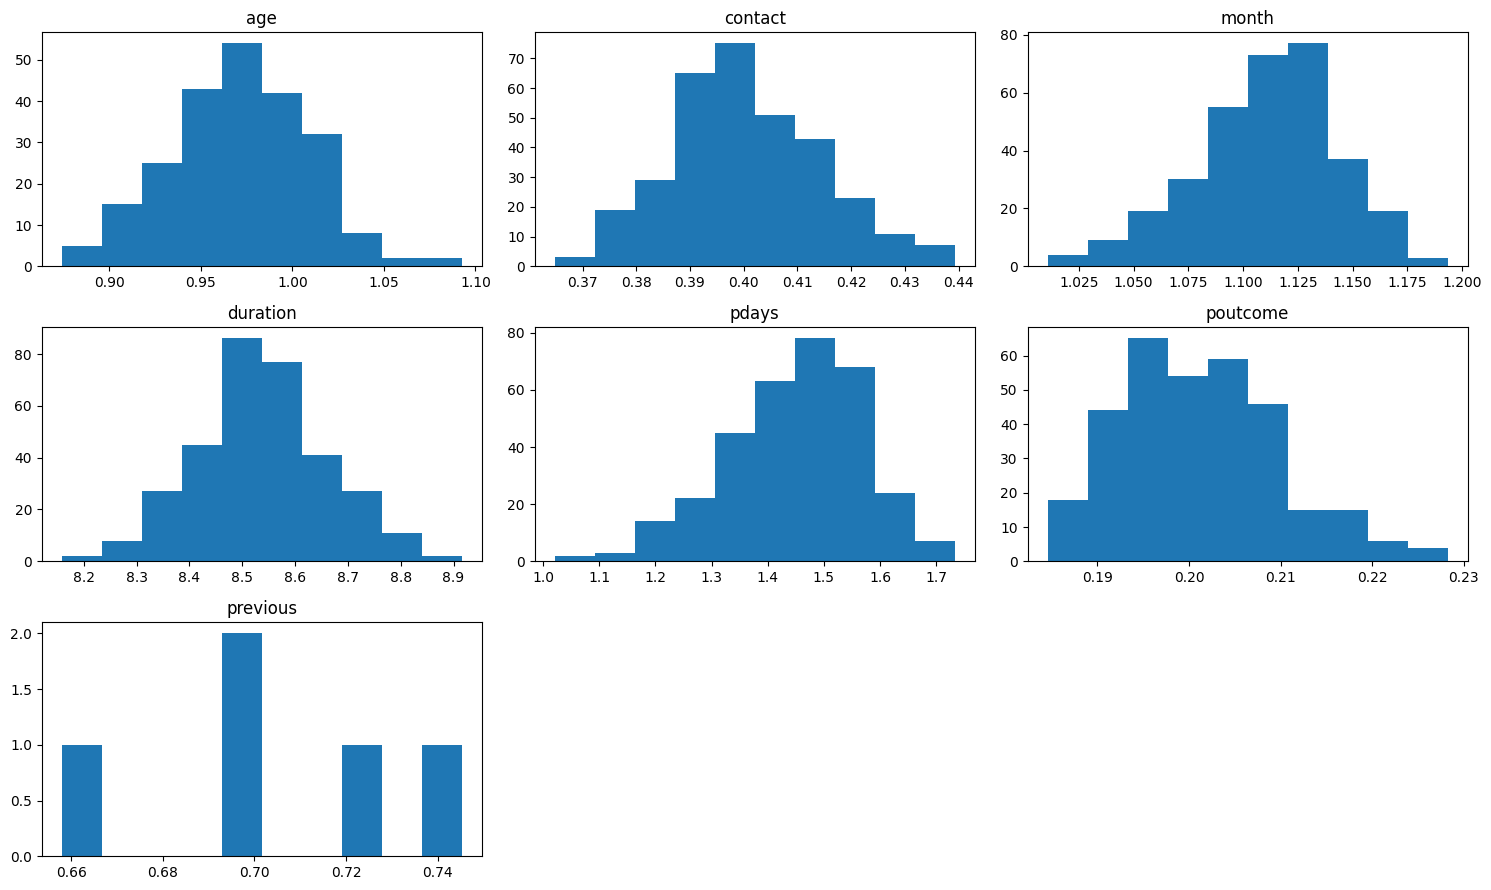

method: swapping, model_count: 204


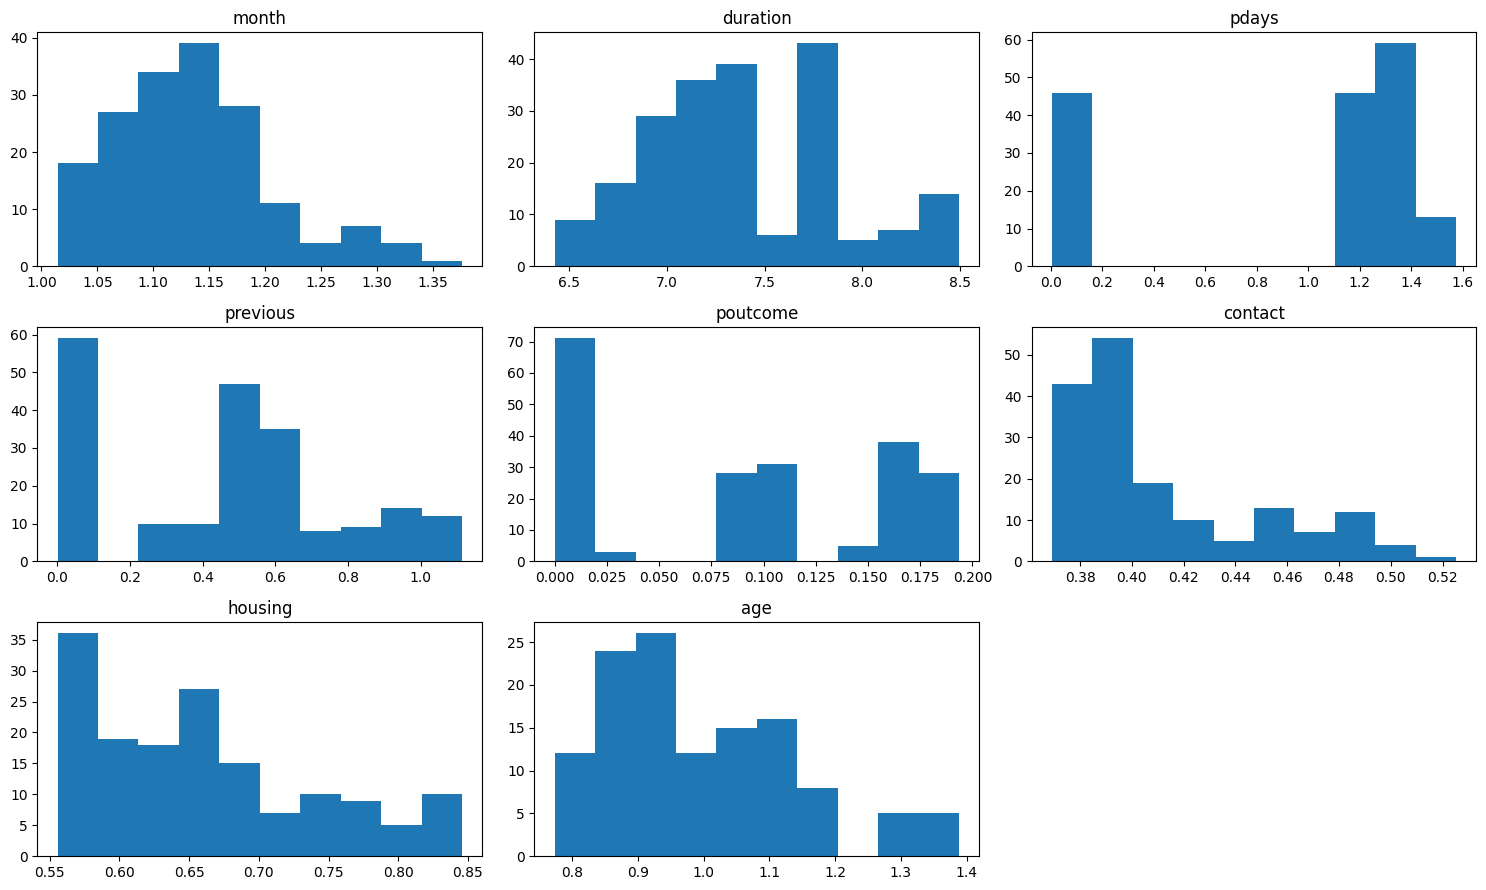

method: hybrid, model_count: 593


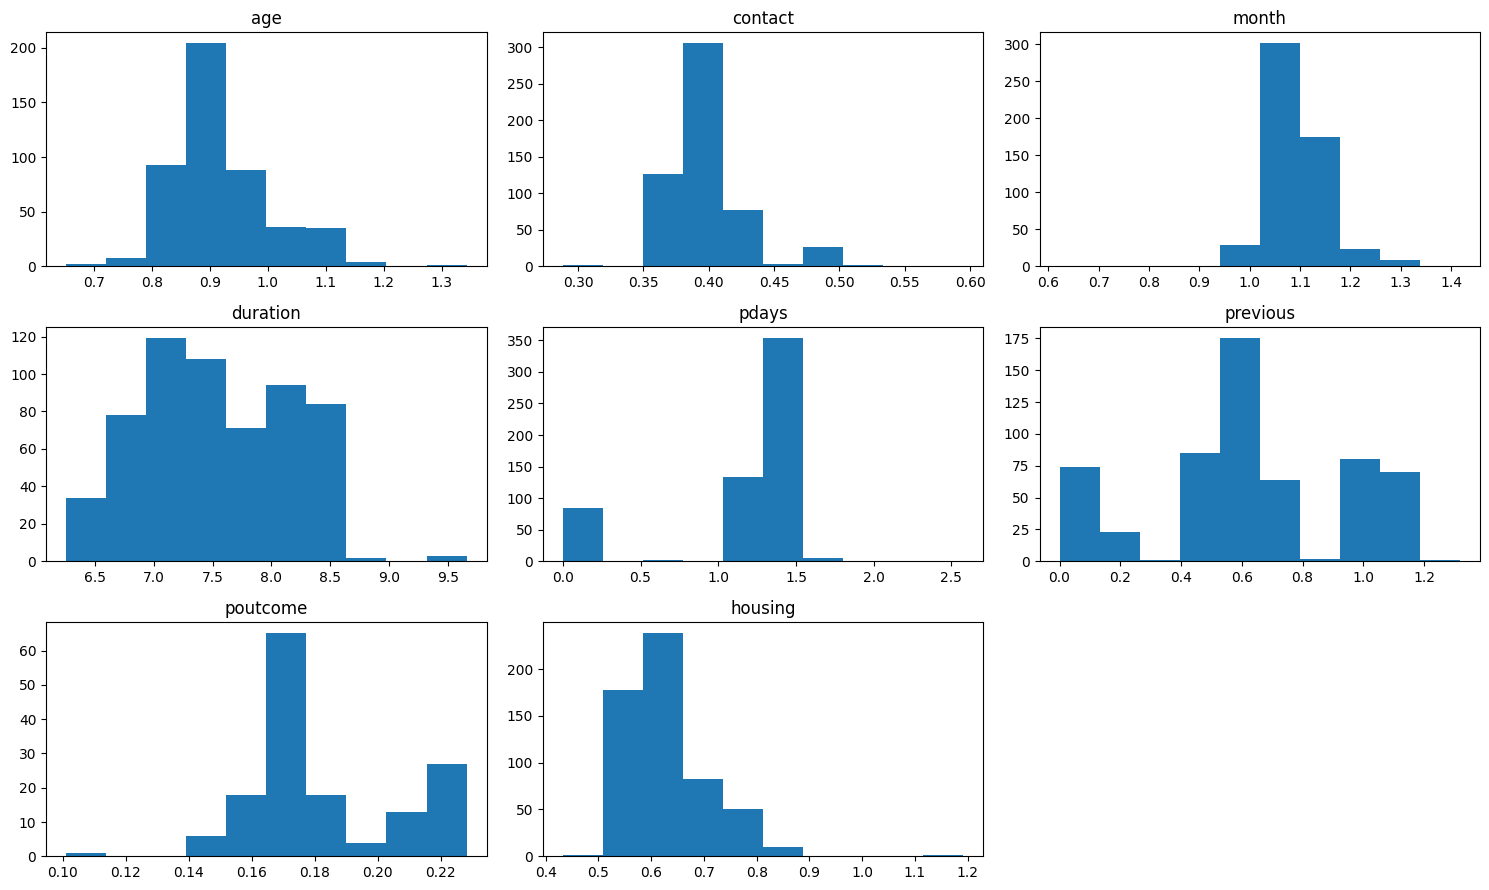

In [19]:
show_variable_importance(all_datasets_results, 'bank')

In [21]:
show_model_reliance(all_datasets_results, "bank")

method: uniform__ellipsoid_sampling, model_count: 142
	age: 1.9343704975037965 - 0.3484478733342782
	contact: 0.6889732139740898 - 0.1740552206986817
	duration: 10.153202000309216 - 6.774980359903619
	housing: 1.1162491727373063 - 0.3585618685023598
	month: 1.6155058779716436 - 0.41454422705742083
	pdays: 3.0362623869289167 - 0.0015999006291982653
	poutcome: 0.32258249987573784 - 0.09668608907463895
	previous: 1.338567383575004 - 0.07055888993951481
method: uniform_surface_ellipsoid_sampling, model_count: 108
	age: 2.134100242514128 - 0.3076609698418915
	contact: 0.7793949514878797 - 0.20325082870503106
	duration: 9.408703281137745 - 6.581274337260141
	housing: 1.1014924131294668 - 0.36753026546642603
	month: 1.7694404860890214 - 0.3497706775989825
	pdays: 3.3981431552210446 - 0.002129963903186851
	poutcome: 0.3347664735328947 - 0.08026065043125837
	previous: 1.3952927408802418 - 0.0692430132279258
method: poisson__ellipsoid_sampling, model_count: 105
	age: 1.6601853023815785 - 0.38179